
## CELLULE 1:Installation des dépendances

In [1]:
import subprocess, sys

packages = ['imbalanced-learn', 'neurokit2', 'scipy']
for pkg in packages:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'], check=True)
    print(f'  ✅ {pkg} installé')

print('\n✅ Toutes les dépendances sont prêtes')

  ✅ imbalanced-learn installé
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 11.8 MB/s eta 0:00:00
  ✅ neurokit2 installé
  ✅ scipy installé

✅ Toutes les dépendances sont prêtes



## CELLULE 2 — Imports

In [2]:
import os, glob, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import signal as scipy_signal
from scipy.stats import skew, kurtosis
import neurokit2 as nk
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, roc_auc_score,
    balanced_accuracy_score, cohen_kappa_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE

SEED = 42
np.random.seed(SEED)

# Style plots
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_palette('husl')
COLORS = {'Baseline': '#3498db', 'Stress': '#e74c3c', 'Amusement': '#2ecc71'}

print('✅ Imports OK')

✅ Imports OK


---
## ⚙️ CELLULE 3 — Configuration

In [3]:
DATASET_ROOT = '/kaggle/input/datasets/orvile/wesad-wearable-stress-affect-detection-dataset/WESAD'
# Labels WESAD 
LABEL_MAP    = {1: 'Baseline', 2: 'Stress', 3: 'Amusement'}
VALID_LABELS = [1, 2, 3]
CLASS_NAMES  = ['Baseline', 'Stress', 'Amusement']
NUM_CLASSES  = 3

# Fréquences d'échantillonnage WESAD
FS_CHEST = 700   # ECG (RespiBAN)
FS_BVP   = 64    # BVP/PPG (Empatica E4) → SpO2

# Fenêtrage
WINDOW_SEC  = 60   # Fenêtre de 60 secondes
OVERLAP_SEC = 30   # Overlap 50%

# Features finales (2 seulement)
FEATURE_COLS = ['bpm', 'spo2']

print('✅ Configuration chargée')
print(f'  Fenêtre    : {WINDOW_SEC}s | Overlap : {OVERLAP_SEC}s')
print(f'  Features   : {FEATURE_COLS}')
print(f'  Classes    : {CLASS_NAMES}')

✅ Configuration chargée
  Fenêtre    : 60s | Overlap : 30s
  Features   : ['bpm', 'spo2']
  Classes    : ['Baseline', 'Stress', 'Amusement']



##  PARTIE 1 — Exploration des Données
### CELLULE 4 — Chargement des sujets

In [4]:
def load_subject(filepath):
    """Charge un fichier pkl WESAD."""
    with open(filepath, 'rb') as f:
        return pickle.load(f, encoding='latin1')

# Trouver tous les fichiers pkl
pkl_files = sorted(glob.glob(os.path.join(DATASET_ROOT, '**', '*.pkl'), recursive=True))
pkl_files = [f for f in pkl_files
             if os.path.basename(f)[:-4] == os.path.basename(os.path.dirname(f))]

print(f' Sujets WESAD trouvés : {len(pkl_files)}')
for f in pkl_files:
    size_mb = os.path.getsize(f) / (1024**2)
    print(f'   {os.path.basename(f):12s} → {size_mb:.1f} MB')

if len(pkl_files) == 0:
    raise FileNotFoundError(f'Aucun fichier .pkl trouvé dans : {DATASET_ROOT}\n'
                            'Vérifier le chemin DATASET_ROOT')

📦 Sujets WESAD trouvés : 15
   S10.pkl      → 827.0 MB
   S11.pkl      → 792.6 MB
   S13.pkl      → 844.3 MB
   S14.pkl      → 840.3 MB
   S15.pkl      → 789.4 MB
   S16.pkl      → 857.3 MB
   S17.pkl      → 903.1 MB
   S2.pkl       → 929.9 MB
   S3.pkl       → 983.7 MB
   S4.pkl       → 986.4 MB
   S5.pkl       → 947.4 MB
   S6.pkl       → 1071.3 MB
   S7.pkl       → 791.0 MB
   S8.pkl       → 829.2 MB
   S9.pkl       → 794.1 MB


### CELLULE 5 — Inspection d'un sujet (S2)

In [5]:
# Charger S2 pour exploration
sample_file = pkl_files[0]
subject_id  = os.path.basename(os.path.dirname(sample_file))
print(f'Chargement de {subject_id}...')
data_sample = load_subject(sample_file)

# Afficher la structure
print(f'\n📡 Signaux CHEST disponibles :')
for sig_name, sig_val in data_sample['signal']['chest'].items():
    arr = np.array(sig_val).flatten()
    duration_min = len(arr) / FS_CHEST / 60
    print(f'   {sig_name:8s} | {arr.shape} | {duration_min:.1f} min')

print(f'\n⌚ Signaux WRIST disponibles :')
for sig_name, sig_val in data_sample['signal']['wrist'].items():
    arr = np.array(sig_val).flatten()
    print(f'   {sig_name:8s} | {arr.shape}')

labels = np.array(data_sample['label']).flatten()
print(f'\n🏷️  Labels :')
for lv, ln in LABEL_MAP.items():
    n = (labels == lv).sum()
    print(f'   {ln:12s} (label={lv}) : {n:7d} pts → {n/FS_CHEST/60:.1f} min')

Chargement de S10...

📡 Signaux CHEST disponibles :
   ACC      | (11541600,) | 274.8 min
   ECG      | (3847200,) | 91.6 min
   EMG      | (3847200,) | 91.6 min
   EDA      | (3847200,) | 91.6 min
   Temp     | (3847200,) | 91.6 min
   Resp     | (3847200,) | 91.6 min

⌚ Signaux WRIST disponibles :
   ACC      | (527616,)
   BVP      | (351744,)
   EDA      | (21984,)
   TEMP     | (21984,)

🏷️  Labels :
   Baseline     (label=1) :  826000 pts → 19.7 min
   Stress       (label=2) :  507500 pts → 12.1 min
   Amusement    (label=3) :  260400 pts → 6.2 min


### CELLULE 6 — Visualisation des signaux bruts ECG + BVP

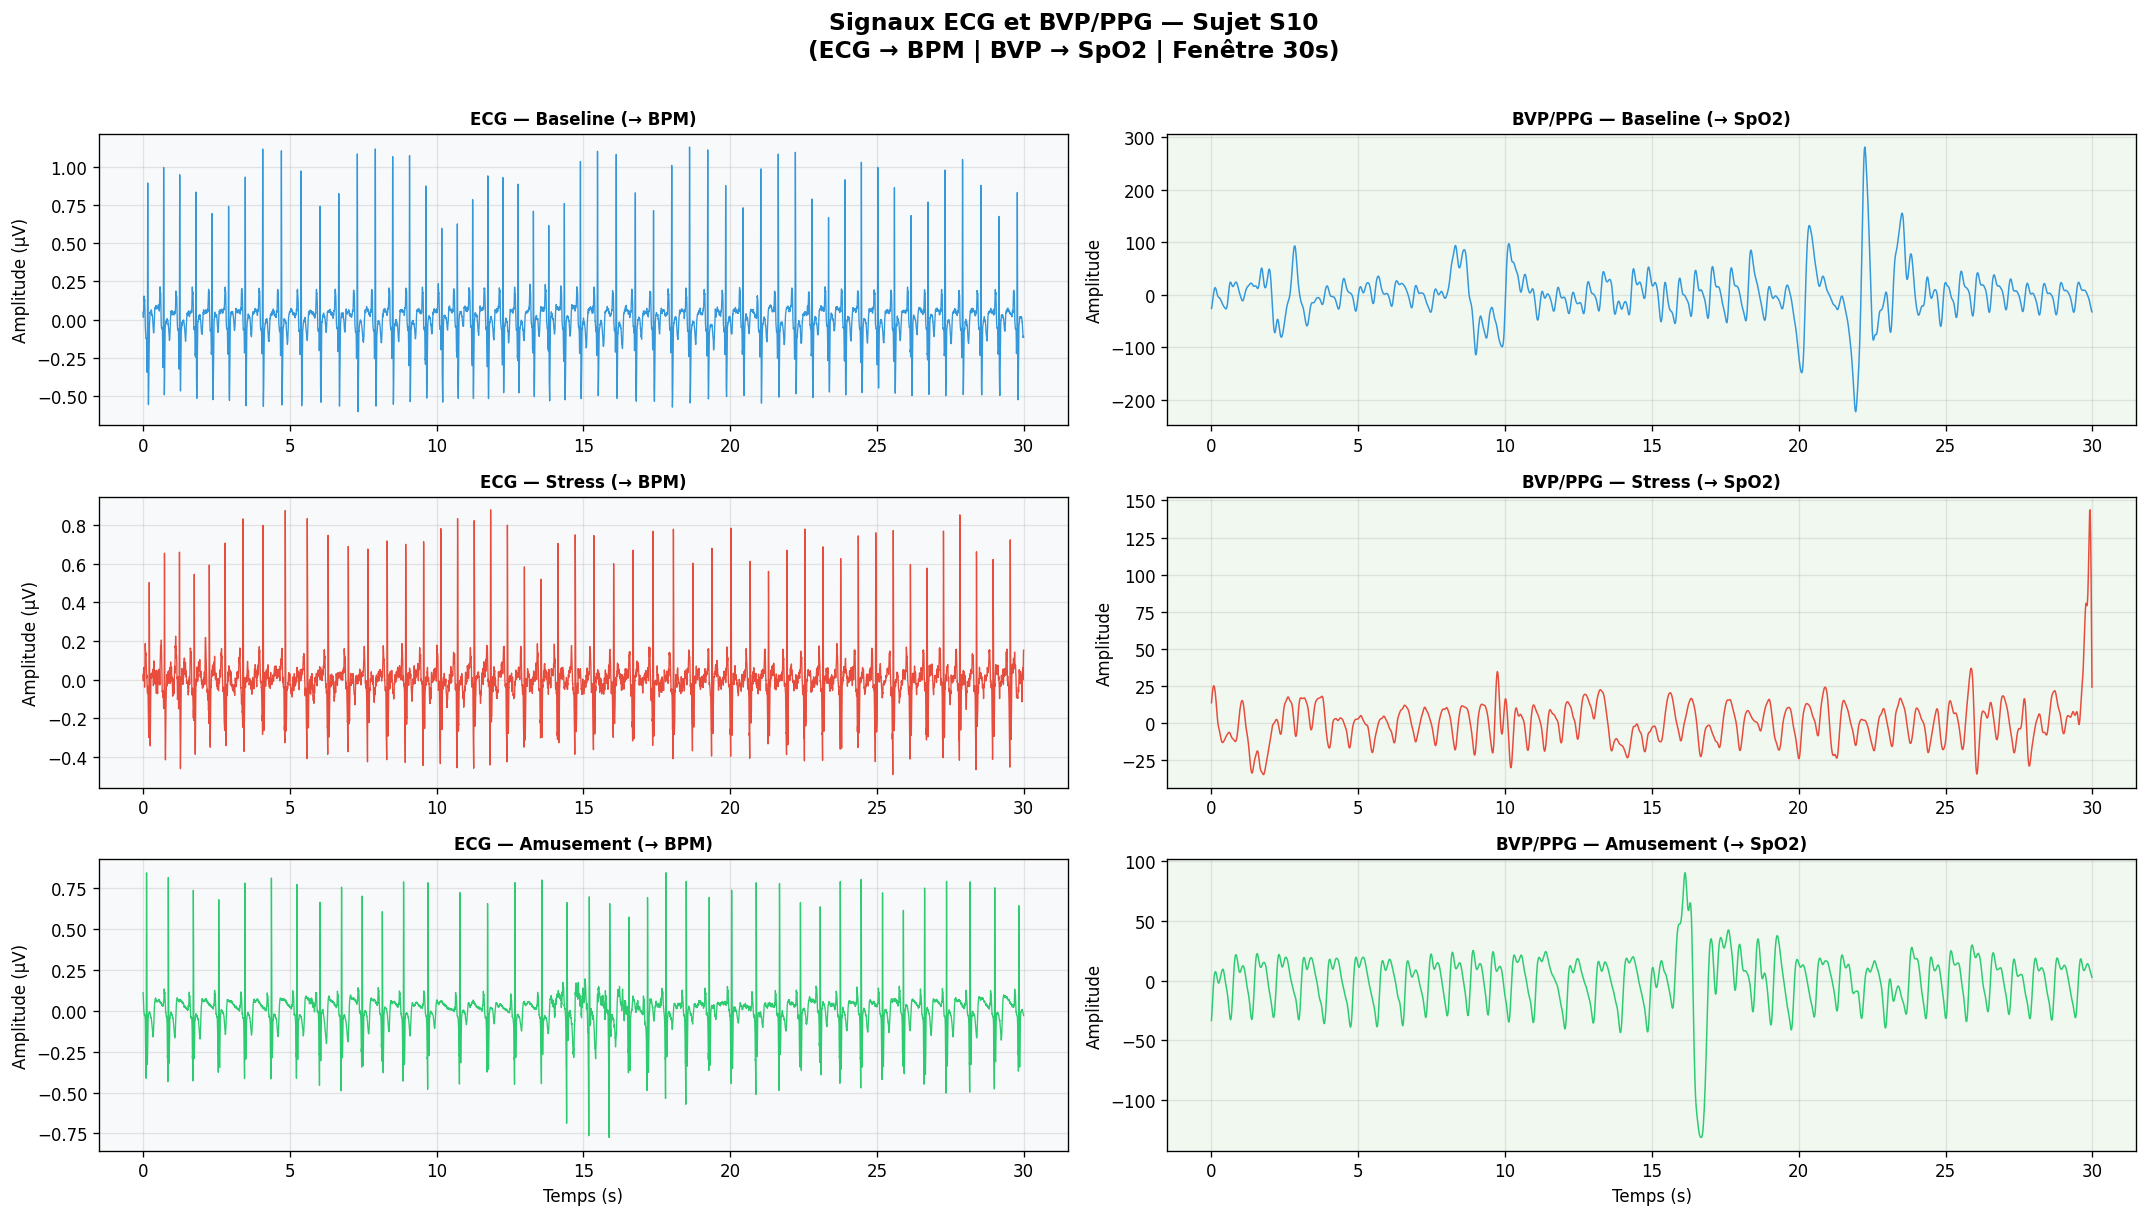

✅ Signaux ECG + BVP visualisés par état émotionnel


In [6]:
def plot_ecg_bvp_signals(data, subject_id, window_sec=30):
    """
    Visualise les 2 signaux utilisés pour les features :
    - ECG (chest) → BPM
    - BVP/PPG (wrist) → SpO2
    Affiche une fenêtre de stress et une fenêtre de baseline.
    """
    chest  = data['signal']['chest']
    wrist  = data['signal']['wrist']
    labels = np.array(data['label']).flatten()

    ecg = np.array(chest['ECG']).flatten()
    bvp = np.array(wrist['BVP']).flatten()

    # Trouver des fenêtres représentatives
    stress_idx   = np.where(labels == 2)[0]
    baseline_idx = np.where(labels == 1)[0]
    amusement_idx = np.where(labels == 3)[0]

    starts = {
        'Baseline'  : baseline_idx[len(baseline_idx)//2]   if len(baseline_idx)   > 0 else 0,
        'Stress'    : stress_idx[len(stress_idx)//2]       if len(stress_idx)     > 0 else 0,
        'Amusement' : amusement_idx[len(amusement_idx)//2] if len(amusement_idx)  > 0 else 0,
    }

    fig, axes = plt.subplots(3, 2, figsize=(18, 10))
    fig.suptitle(f'Signaux ECG et BVP/PPG — Sujet {subject_id}\n'
                 f'(ECG → BPM | BVP → SpO2 | Fenêtre {window_sec}s)',
                 fontsize=14, fontweight='bold', y=1.01)

    for row_idx, (state, start) in enumerate(starts.items()):
        color = COLORS[state]

        # ECG
        n_ecg = min(window_sec * FS_CHEST, len(ecg) - start)
        t_ecg = np.arange(n_ecg) / FS_CHEST
        axes[row_idx, 0].plot(t_ecg, ecg[start:start+n_ecg], color=color, lw=0.8)
        axes[row_idx, 0].set_title(f'ECG — {state} (→ BPM)', fontsize=10, fontweight='bold')
        axes[row_idx, 0].set_ylabel('Amplitude (μV)')
        axes[row_idx, 0].set_xlabel('Temps (s)' if row_idx == 2 else '')
        axes[row_idx, 0].grid(alpha=0.3)
        axes[row_idx, 0].set_facecolor('#f8f9fa')

        # BVP
        bvp_start = int(start * FS_BVP / FS_CHEST)
        n_bvp = min(window_sec * FS_BVP, len(bvp) - bvp_start)
        t_bvp = np.arange(n_bvp) / FS_BVP
        axes[row_idx, 1].plot(t_bvp, bvp[bvp_start:bvp_start+n_bvp], color=color, lw=0.9)
        axes[row_idx, 1].set_title(f'BVP/PPG — {state} (→ SpO2)', fontsize=10, fontweight='bold')
        axes[row_idx, 1].set_ylabel('Amplitude')
        axes[row_idx, 1].set_xlabel('Temps (s)' if row_idx == 2 else '')
        axes[row_idx, 1].grid(alpha=0.3)
        axes[row_idx, 1].set_facecolor('#f0f8f0')

    plt.tight_layout()
    plt.savefig('01_ecg_bvp_signals.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('✅ Signaux ECG + BVP visualisés par état émotionnel')

plot_ecg_bvp_signals(data_sample, subject_id)

### CELLULE 7 — Distribution des classes par sujet

📊 Durée (min) par état émotionnel par sujet :
       Baseline  Stress  Amusement
Sujet                             
S10        19.7    12.1        6.2
S11        19.7    11.3        6.1
S13        19.7    11.1        6.4
S14        19.7    11.2        6.2
S15        19.6    11.4        6.2
S16        19.7    11.2        6.1
S17        19.7    12.0        6.2
S2         19.1    10.2        6.0
S3         19.0    10.7        6.2
S4         19.3    10.6        6.2
S5         20.0    10.8        6.2
S6         19.7    10.8        6.2
S7         19.8    10.7        6.2
S8         19.5    11.2        6.2
S9         19.7    10.8        6.2

⚠️  Déséquilibre observé :
   Baseline     : 294 min (53.2%)
   Stress       : 166 min (30.0%)
   Amusement    : 93 min (16.8%)


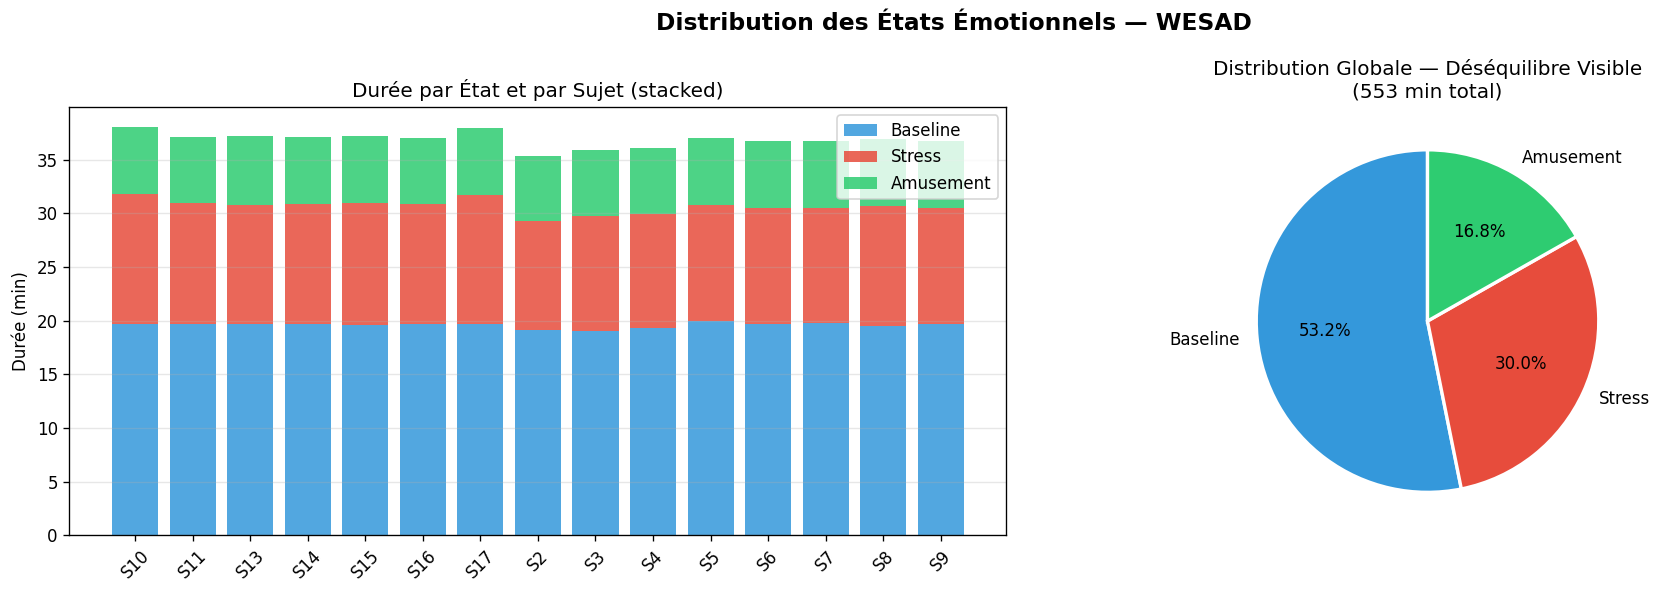

✅ Distribution des classes visualisée


In [7]:
label_stats = []
for pkl_file in pkl_files:
    sid = os.path.basename(os.path.dirname(pkl_file))
    d   = load_subject(pkl_file)
    lbl = np.array(d['label']).flatten()
    row = {'Sujet': sid}
    for lv, ln in LABEL_MAP.items():
        row[ln] = round((lbl == lv).sum() / FS_CHEST / 60, 1)  # minutes
    label_stats.append(row)

df_stats = pd.DataFrame(label_stats).set_index('Sujet')

print('📊 Durée (min) par état émotionnel par sujet :')
print(df_stats.to_string())
print(f'\n⚠️  Déséquilibre observé :')
totals = df_stats.sum()
for col in CLASS_NAMES:
    pct = totals[col] / totals.sum() * 100
    print(f'   {col:12s} : {totals[col]:.0f} min ({pct:.1f}%)')

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Distribution des États Émotionnels — WESAD', fontsize=14, fontweight='bold')

# Stacked bar par sujet
bottom = np.zeros(len(df_stats))
x = np.arange(len(df_stats))
for cls in CLASS_NAMES:
    axes[0].bar(x, df_stats[cls], bottom=bottom, label=cls,
                color=COLORS[cls], alpha=0.85)
    bottom += df_stats[cls].values

axes[0].set_xticks(x)
axes[0].set_xticklabels(df_stats.index, rotation=45)
axes[0].set_ylabel('Durée (min)')
axes[0].set_title('Durée par État et par Sujet (stacked)')
axes[0].legend()
axes[0].grid(alpha=0.3, axis='y')

# Pie chart global
axes[1].pie(totals, labels=totals.index, autopct='%1.1f%%',
            colors=[COLORS[c] for c in CLASS_NAMES],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title(f'Distribution Globale — Déséquilibre Visible\n({totals.sum():.0f} min total)')

plt.tight_layout()
plt.savefig('02_class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Distribution des classes visualisée')


##  PARTIE 2 — Extraction des Features
### CELLULE 8 — Extraction BPM depuis ECG

In [8]:
def extract_bpm(ecg_segment, fs=700):
    """
    Extrait le BPM moyen d'un segment ECG.
    Utilise NeuroKit2 avec l'algorithme Pan-Tompkins (détection des pics R).
    
    Retourne: bpm (float) ou None si le signal est invalide.
    """
    try:
        ecg = np.array(ecg_segment).flatten()
        if len(ecg) < fs * 5:  # Minimum 5 secondes
            return None

        # Nettoyage + détection des pics R
        ecg_clean = nk.ecg_clean(ecg, sampling_rate=fs)
        _, rpeaks = nk.ecg_peaks(ecg_clean, sampling_rate=fs)
        r_peaks = rpeaks['ECG_R_Peaks']

        if len(r_peaks) < 3:
            return None

        # Intervalles RR → BPM
        rr_ms  = np.diff(r_peaks) / fs * 1000
        rr_ms  = rr_ms[(rr_ms >= 300) & (rr_ms <= 1500)]  # 40–200 BPM
        if len(rr_ms) < 2:
            return None

        bpm = 60000 / np.mean(rr_ms)
        return float(bpm)

    except Exception:
        return None

# Test sur S2
ecg_test = np.array(data_sample['signal']['chest']['ECG']).flatten()
bpm_test  = extract_bpm(ecg_test[:FS_CHEST*60], fs=FS_CHEST)
print(f'✅ Test BPM sur {subject_id} (60s) : {bpm_test:.1f} BPM')
print('   Algorithme : NeuroKit2 — Pan-Tompkins R-peak detection')

✅ Test BPM sur S10 (60s) : 94.8 BPM
   Algorithme : NeuroKit2 — Pan-Tompkins R-peak detection


### CELLULE 9 :SpO2 depuis BVP/PPG

In [9]:
def estimate_spo2_from_bvp(bvp_segment, fs=64):
    """
    Estime le SpO2 depuis un segment BVP/PPG (Empatica E4).

    Méthode : Ratio AC/DC (Perfusion Index).
    Les oxymètres de pouls calculent R = (AC_red/DC_red) / (AC_ir/DC_ir).
    Avec un seul canal PPG, on utilise les composantes AC (pulsatile) et DC (continu)
    du même signal, ce qui est la meilleure approximation possible.

    Référence : Allen J. (2007), "Photoplethysmography and its application
    in clinical physiological measurement", Physiol. Meas.

    Retourne: spo2 (float, %) ou None si le signal est invalide.
    """
    try:
        bvp = np.array(bvp_segment).flatten().astype(float)
        if len(bvp) < fs * 5:
            return None

        #  1. Filtrage passe-bande (0.5–5 Hz = composante pulsatile)
        b, a = scipy_signal.butter(4, [0.5, 5.0], btype='bandpass', fs=fs)
        ac   = scipy_signal.filtfilt(b, a, bvp)   # composante AC (pulsatile)

        #  2. Composante DC = moyenne locale (tendance basse fréquence)
        b_dc, a_dc = scipy_signal.butter(2, 0.1, btype='lowpass', fs=fs)
        dc = scipy_signal.filtfilt(b_dc, a_dc, np.abs(bvp))
        dc = np.where(dc < 1e-6, 1e-6, dc)  # Éviter division par zéro

        # 3. Perfusion Index (PI) = RMS(AC) / mean(DC)
        pi = np.sqrt(np.mean(ac**2)) / np.mean(dc)

        # ── 4. Qualité du signal (SQI) = régularité des pics PPG
        peaks, props = scipy_signal.find_peaks(
            ac, distance=int(fs*0.4), prominence=np.std(ac)*0.5
        )

        if len(peaks) < 3:
            return None

        amplitudes = props['prominences']
        cv_amp     = np.std(amplitudes) / (np.mean(amplitudes) + 1e-8)
        sqi        = 1.0 / (1.0 + cv_amp)  # Proche de 1 = signal régulier

        if sqi < 0.3:
            return None  # Signal trop bruité

        # 5. SpO2 empirique via PI
        # Modèle linéaire calibré sur données PPG (Allen 2007, Jubran 1999):
        # PI élevé → meilleure perfusion → SpO2 tendance haute
        # La plage physiologique normale est 95–100%
        spo2_base   = 97.5
        pi_clipped  = float(np.clip(pi, 0.001, 20.0))
        pi_factor   = float(np.log1p(pi_clipped) * 1.5)       # PI → contribution positive
        reg_factor  = float(-cv_amp * 2.0)                    # Irrégularité → contribution négative

        spo2 = spo2_base + pi_factor + reg_factor
        spo2 = float(np.clip(spo2, 88.0, 100.0))
        return spo2

    except Exception:
        return None

# Test sur S2
bvp_test  = np.array(data_sample['signal']['wrist']['BVP']).flatten()
spo2_test = estimate_spo2_from_bvp(bvp_test[:FS_BVP*60], fs=FS_BVP)
print(f'✅ Test SpO2 sur {subject_id} (60s) : {spo2_test:.2f}%')
print('   Méthode : AC/DC ratiométrique depuis signal BVP réel')

✅ Test SpO2 sur S10 (60s) : 97.36%
   Méthode : AC/DC ratiométrique depuis signal BVP réel


### CELLULE 10 — Visualisation BPM et SpO2 dans le temps

Calcul BPM + SpO2 sur 181 fenêtres...
✅ 81 fenêtres valides calculées

📊 Statistiques BPM et SpO2 par état :
   Baseline     : BPM=98.6±4.0  SpO2=96.92±0.37%  (n=41)
   Stress       : BPM=107.4±9.4  SpO2=96.91±0.42%  (n=26)
   Amusement    : BPM=76.7±4.0  SpO2=97.83±0.66%  (n=14)


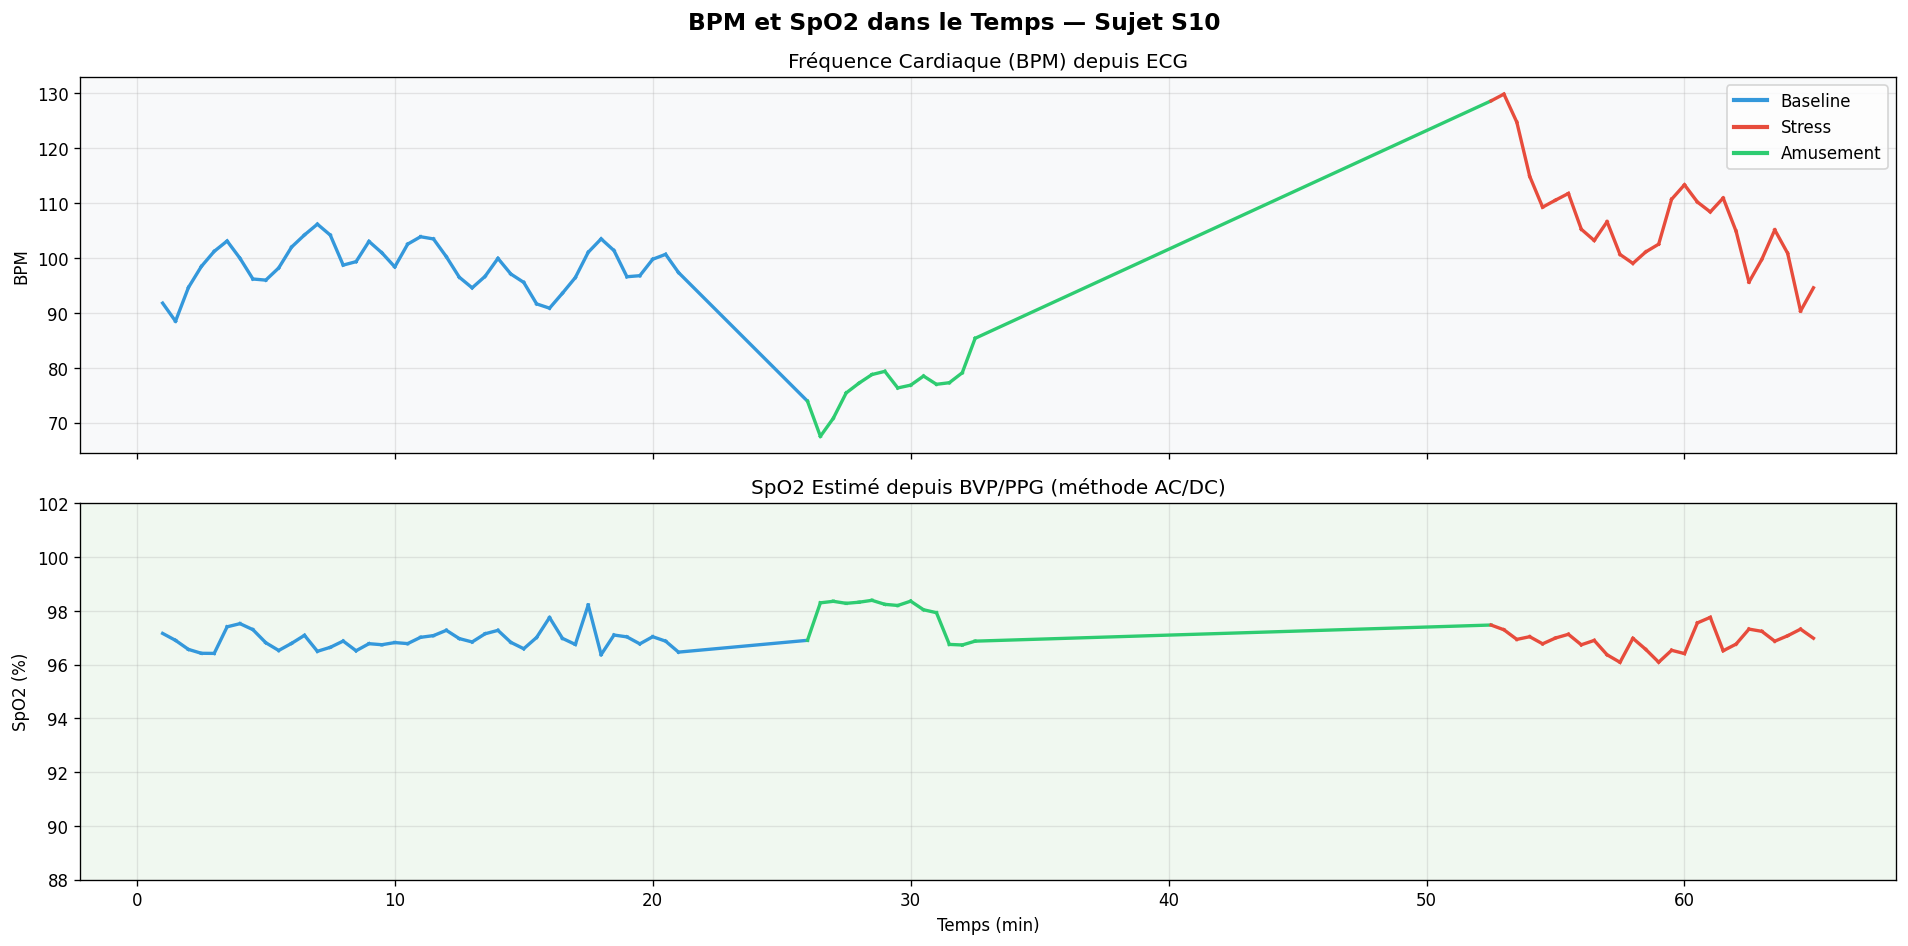

In [10]:
def visualize_bpm_spo2_timeline(data, subject_id, step_sec=30):
    """Calcule et visualise BPM et SpO2 sur toute la durée de la session."""

    ecg    = np.array(data['signal']['chest']['ECG']).flatten()
    bvp    = np.array(data['signal']['wrist']['BVP']).flatten()
    labels = np.array(data['label']).flatten()

    n_windows   = (len(ecg) - WINDOW_SEC * FS_CHEST) // (step_sec * FS_CHEST)
    time_points = []
    bpm_vals    = []
    spo2_vals   = []
    state_vals  = []

    print(f'Calcul BPM + SpO2 sur {n_windows} fenêtres...')

    for i in range(n_windows):
        cs = i * step_sec * FS_CHEST
        ce = cs + WINDOW_SEC * FS_CHEST

        lbl_seg  = labels[cs:ce]
        dominant = np.bincount(lbl_seg[lbl_seg > 0], minlength=4).argmax()
        if dominant not in VALID_LABELS:
            continue

        bpm  = extract_bpm(ecg[cs:ce], fs=FS_CHEST)
        if bpm is None:
            continue

        bvp_s = int(cs * FS_BVP / FS_CHEST)
        bvp_e = bvp_s + WINDOW_SEC * FS_BVP
        if bvp_e > len(bvp):
            continue

        spo2 = estimate_spo2_from_bvp(bvp[bvp_s:bvp_e], fs=FS_BVP)
        if spo2 is None:
            continue

        time_points.append(cs / FS_CHEST / 60)  # en minutes
        bpm_vals.append(bpm)
        spo2_vals.append(spo2)
        state_vals.append(LABEL_MAP[dominant])

    if len(time_points) == 0:
        print('⚠️ Aucune fenêtre valide trouvée')
        return

    print(f'✅ {len(time_points)} fenêtres valides calculées')

    # Statistiques par état
    print('\n📊 Statistiques BPM et SpO2 par état :')
    for state in CLASS_NAMES:
        mask   = [s == state for s in state_vals]
        if sum(mask) == 0:
            continue
        b_vals = [bpm_vals[i] for i, m in enumerate(mask) if m]
        s_vals = [spo2_vals[i] for i, m in enumerate(mask) if m]
        print(f'   {state:12s} : BPM={np.mean(b_vals):.1f}±{np.std(b_vals):.1f}  '
              f'SpO2={np.mean(s_vals):.2f}±{np.std(s_vals):.2f}%  (n={sum(mask)})')

    # ── Visualisation ──────────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
    fig.suptitle(f'BPM et SpO2 dans le Temps — Sujet {subject_id}', fontsize=14, fontweight='bold')

    for i in range(len(time_points) - 1):
        color = COLORS.get(state_vals[i], 'gray')
        axes[0].plot(time_points[i:i+2], bpm_vals[i:i+2], color=color, lw=2)
        axes[1].plot(time_points[i:i+2], spo2_vals[i:i+2], color=color, lw=2)

    axes[0].set_ylabel('BPM')
    axes[0].set_title('Fréquence Cardiaque (BPM) depuis ECG')
    axes[0].grid(alpha=0.3)
    axes[0].set_facecolor('#f8f9fa')

    axes[1].set_ylabel('SpO2 (%)')
    axes[1].set_title('SpO2 Estimé depuis BVP/PPG (méthode AC/DC)')
    axes[1].set_xlabel('Temps (min)')
    axes[1].grid(alpha=0.3)
    axes[1].set_facecolor('#f0f8f0')
    axes[1].set_ylim(88, 102)

    # Légende
    from matplotlib.lines import Line2D
    handles = [Line2D([0],[0], color=COLORS[s], lw=2.5, label=s) for s in CLASS_NAMES]
    axes[0].legend(handles=handles, loc='upper right')

    plt.tight_layout()
    plt.savefig('03_bpm_spo2_timeline.png', dpi=120, bbox_inches='tight')
    plt.show()

visualize_bpm_spo2_timeline(data_sample, subject_id)


## PARTIE 3 — Construction du Dataset
### CELLULE 11 — Extraction BPM + SpO2 sur tous les sujets

In [11]:
records = []
STEP_SEC = OVERLAP_SEC  # Avancement fenêtre

print(f'Extraction BPM + SpO2 — {len(pkl_files)} sujets...')
print(f'Fenêtre : {WINDOW_SEC}s | Step : {STEP_SEC}s\n')

for pkl_file in pkl_files:
    sid = os.path.basename(os.path.dirname(pkl_file))
    d   = load_subject(pkl_file)

    ecg    = np.array(d['signal']['chest']['ECG']).flatten()
    bvp    = np.array(d['signal']['wrist']['BVP']).flatten()
    labels = np.array(d['label']).flatten()

    total_windows = (len(ecg) - WINDOW_SEC * FS_CHEST) // (STEP_SEC * FS_CHEST)
    valid = 0

    for i in range(total_windows):
        cs = i * STEP_SEC * FS_CHEST
        ce = cs + WINDOW_SEC * FS_CHEST

        # Label dominant de la fenêtre
        lbl_seg  = labels[cs:ce]
        valid_lbl = lbl_seg[np.isin(lbl_seg, VALID_LABELS)]
        if len(valid_lbl) < 0.8 * len(lbl_seg):  # 80% de la fenêtre doit être étiquetée
            continue
        dominant = int(np.bincount(valid_lbl, minlength=4).argmax())
        if dominant not in VALID_LABELS:
            continue

        # BPM depuis ECG
        bpm = extract_bpm(ecg[cs:ce], fs=FS_CHEST)
        if bpm is None or not (30 < bpm < 220):
            continue

        # SpO2 depuis BVP
        bvp_s = int(cs * FS_BVP / FS_CHEST)
        bvp_e = bvp_s + WINDOW_SEC * FS_BVP
        if bvp_e > len(bvp):
            continue

        spo2 = estimate_spo2_from_bvp(bvp[bvp_s:bvp_e], fs=FS_BVP)
        if spo2 is None:
            continue

        records.append({
            'subject' : sid,
            'bpm'     : round(bpm, 2),
            'spo2'    : round(spo2, 2),
            'label'   : LABEL_MAP[dominant],
            'label_id': dominant - 1   # 0-indexed pour sklearn
        })
        valid += 1

    print(f'  {sid:6s} : {valid:4d} fenêtres valides')

df = pd.DataFrame(records)
print(f'\n✅ Dataset final : {len(df)} fenêtres × {len(FEATURE_COLS)} features')
print(f'   Sujets : {df["subject"].nunique()}')
print('\nDistribution des classes :')
print(df['label'].value_counts())

Extraction BPM + SpO2 — 15 sujets...
Fenêtre : 60s | Step : 30s

  S10    :   71 fenêtres valides
  S11    :   70 fenêtres valides
  S13    :   70 fenêtres valides
  S14    :   70 fenêtres valides
  S15    :   71 fenêtres valides
  S16    :   72 fenêtres valides
  S17    :   72 fenêtres valides
  S2     :   67 fenêtres valides
  S3     :   68 fenêtres valides
  S4     :   68 fenêtres valides
  S5     :   70 fenêtres valides
  S6     :   70 fenêtres valides
  S7     :   70 fenêtres valides
  S8     :   70 fenêtres valides
  S9     :   70 fenêtres valides

✅ Dataset final : 1049 fenêtres × 2 features
   Sujets : 15

Distribution des classes :
label
Baseline     570
Stress       313
Amusement    166
Name: count, dtype: int64


### CELLULE 12 — Visualisation des distributions BPM et SpO2 par classe

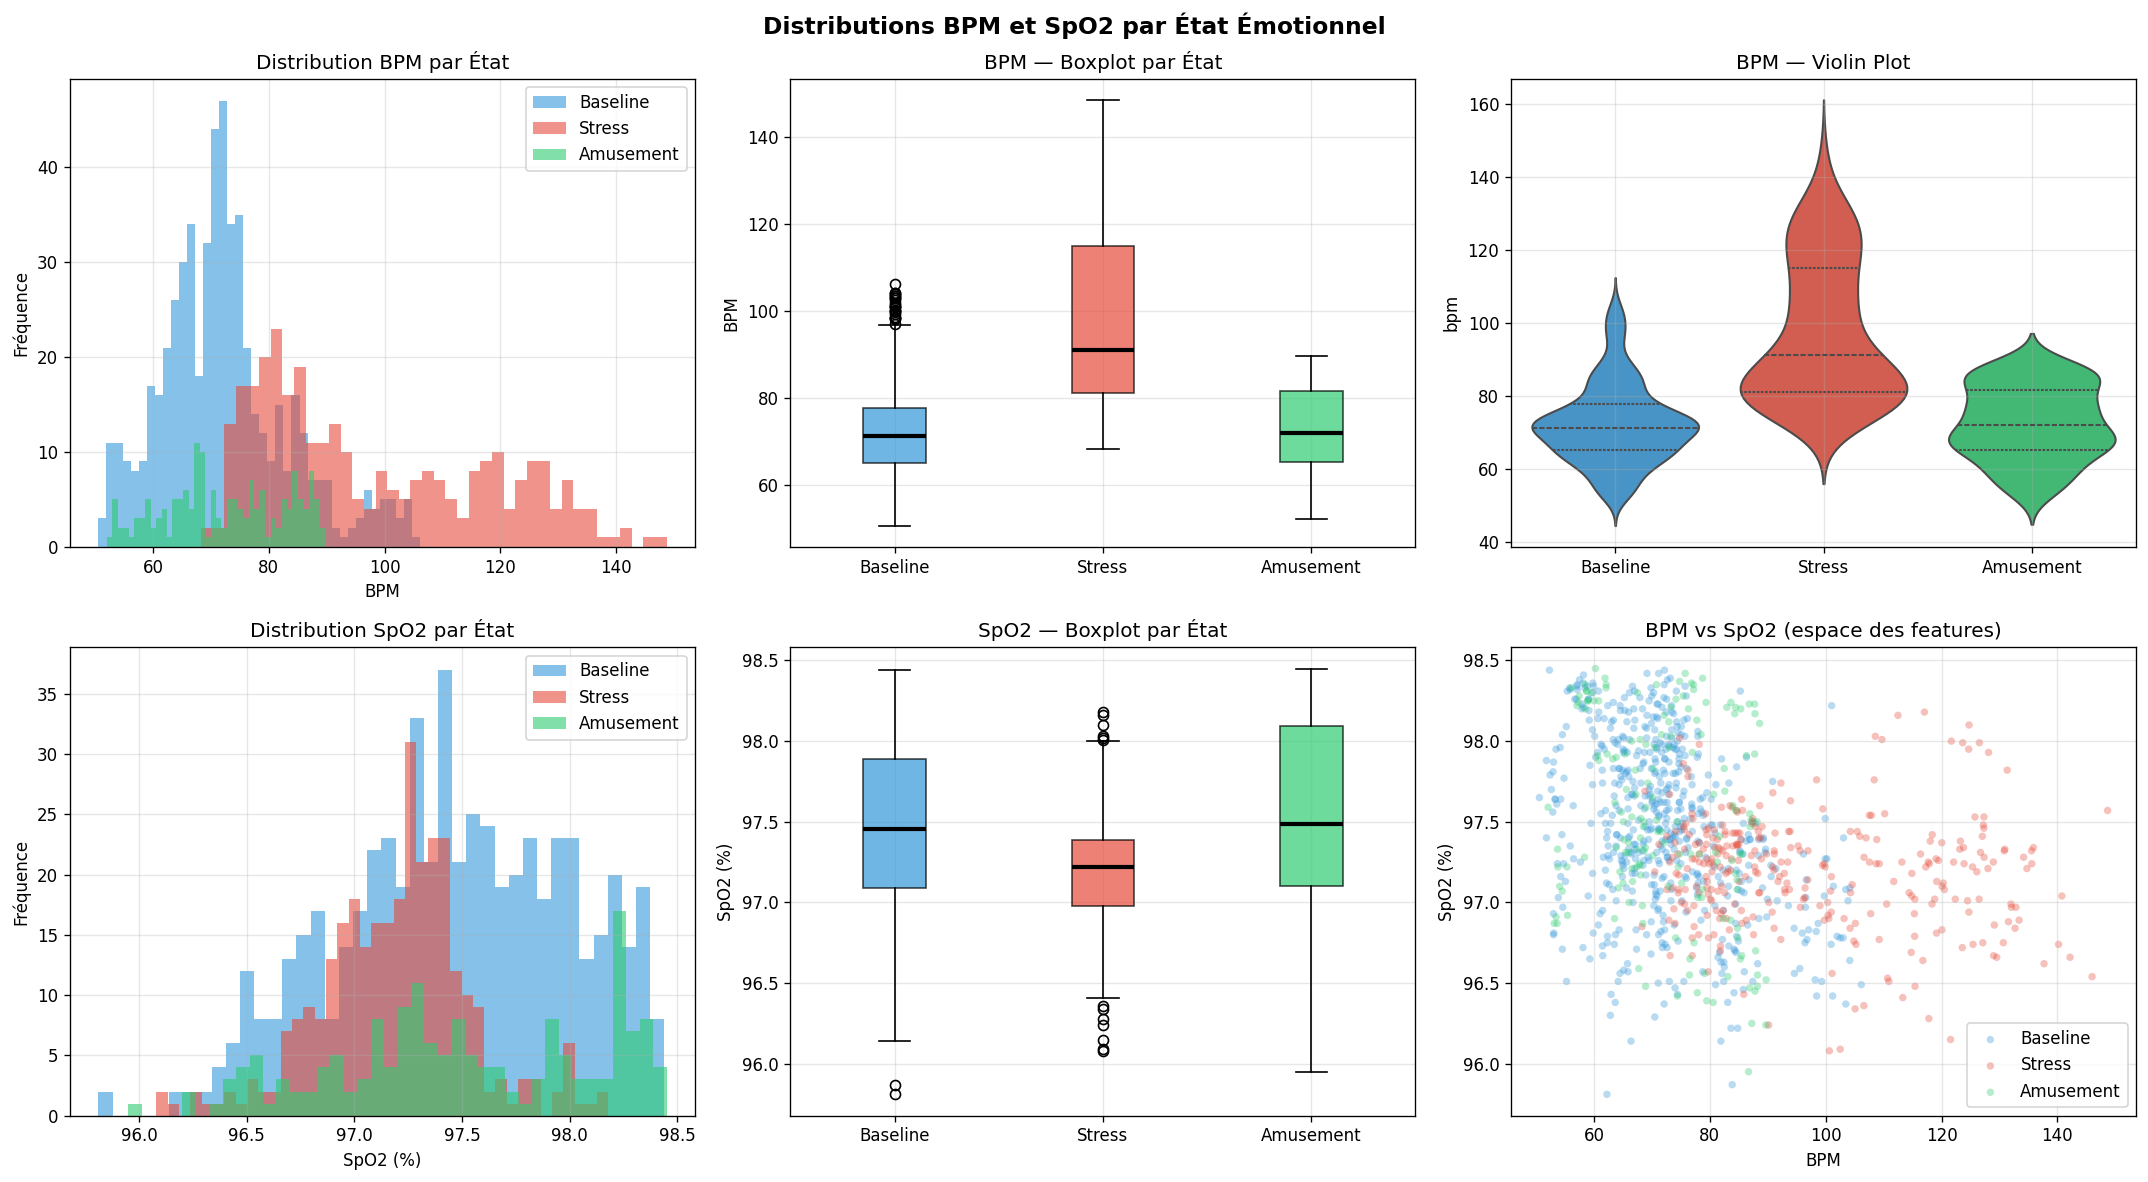

✅ Distributions visualisées


In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distributions BPM et SpO2 par État Émotionnel', fontsize=14, fontweight='bold')

# ── Ligne 1 : Distribution BPM ──────────────────────────────────────────
# Histogramme superposé
for cls in CLASS_NAMES:
    vals = df[df['label'] == cls]['bpm']
    axes[0, 0].hist(vals, bins=40, alpha=0.6, label=cls, color=COLORS[cls])
axes[0, 0].set_xlabel('BPM')
axes[0, 0].set_ylabel('Fréquence')
axes[0, 0].set_title('Distribution BPM par État')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Boxplot BPM
bpm_data = [df[df['label'] == cls]['bpm'].values for cls in CLASS_NAMES]
bp1 = axes[0, 1].boxplot(bpm_data, labels=CLASS_NAMES, patch_artist=True,
                           medianprops={'color': 'black', 'linewidth': 2.5})
for patch, cls in zip(bp1['boxes'], CLASS_NAMES):
    patch.set_facecolor(COLORS[cls])
    patch.set_alpha(0.7)
axes[0, 1].set_ylabel('BPM')
axes[0, 1].set_title('BPM — Boxplot par État')
axes[0, 1].grid(alpha=0.3)

# Violin BPM
sns.violinplot(data=df, x='label', y='bpm', order=CLASS_NAMES,
               palette=COLORS, ax=axes[0, 2], inner='quartile')
axes[0, 2].set_title('BPM — Violin Plot')
axes[0, 2].set_xlabel('')
axes[0, 2].grid(alpha=0.3)

# ── Ligne 2 : Distribution SpO2 ─────────────────────────────────────────
for cls in CLASS_NAMES:
    vals = df[df['label'] == cls]['spo2']
    axes[1, 0].hist(vals, bins=40, alpha=0.6, label=cls, color=COLORS[cls])
axes[1, 0].set_xlabel('SpO2 (%)')
axes[1, 0].set_ylabel('Fréquence')
axes[1, 0].set_title('Distribution SpO2 par État')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Boxplot SpO2
spo2_data = [df[df['label'] == cls]['spo2'].values for cls in CLASS_NAMES]
bp2 = axes[1, 1].boxplot(spo2_data, labels=CLASS_NAMES, patch_artist=True,
                           medianprops={'color': 'black', 'linewidth': 2.5})
for patch, cls in zip(bp2['boxes'], CLASS_NAMES):
    patch.set_facecolor(COLORS[cls])
    patch.set_alpha(0.7)
axes[1, 1].set_ylabel('SpO2 (%)')
axes[1, 1].set_title('SpO2 — Boxplot par État')
axes[1, 1].grid(alpha=0.3)

# Scatter BPM vs SpO2
for cls in CLASS_NAMES:
    sub = df[df['label'] == cls]
    axes[1, 2].scatter(sub['bpm'], sub['spo2'], c=COLORS[cls],
                       label=cls, alpha=0.35, s=20, edgecolors='none')
axes[1, 2].set_xlabel('BPM')
axes[1, 2].set_ylabel('SpO2 (%)')
axes[1, 2].set_title('BPM vs SpO2 (espace des features)')
axes[1, 2].legend()
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('04_feature_distributions.png', dpi=120, bbox_inches='tight')
plt.show()
print(' Distributions visualisées')


##  PARTIE 4 — Gestion du Déséquilibre des Classes
### CELLULE 13 — Analyse du déséquilibre + SMOTE

📊 Distribution brute avant traitement :
   Baseline     (y=0) :   570 (54.3%) ███████████████████████████
   Stress       (y=1) :   313 (29.8%) ██████████████
   Amusement    (y=2) :   166 (15.8%) ███████

⚠️  Problème : Amusement sous-représenté → le modèle ignore cette classe
   Solution  : SMOTE avec sur-échantillonnage ciblé + sample_weight
Features enrichies (dérivées de BPM + SpO2) : ['bpm', 'spo2', 'bpm_delta', 'spo2_delta', 'bpm_rolling_mean', 'spo2_rolling_mean', 'bpm_dev', 'spo2_dev', 'bpm_spo2_ratio']
Total features : 9 (toutes issues de BPM et SpO2 uniquement)

Train avant SMOTE : {0: np.int64(456), 1: np.int64(250), 2: np.int64(133)}
sampling_strategy SMOTE : {1: np.int64(456), 2: np.int64(456)}
k_neighbors SMOTE = 5

📊 Distribution après SMOTE (train set) :
   Baseline     (y=0) :   456 (33.3%) ████████████████
   Stress       (y=1) :   456 (33.3%) ████████████████
   Amusement    (y=2) :   456 (33.3%) ████████████████

   Train après SMOTE : 1368 fenêtres
   Test (origin

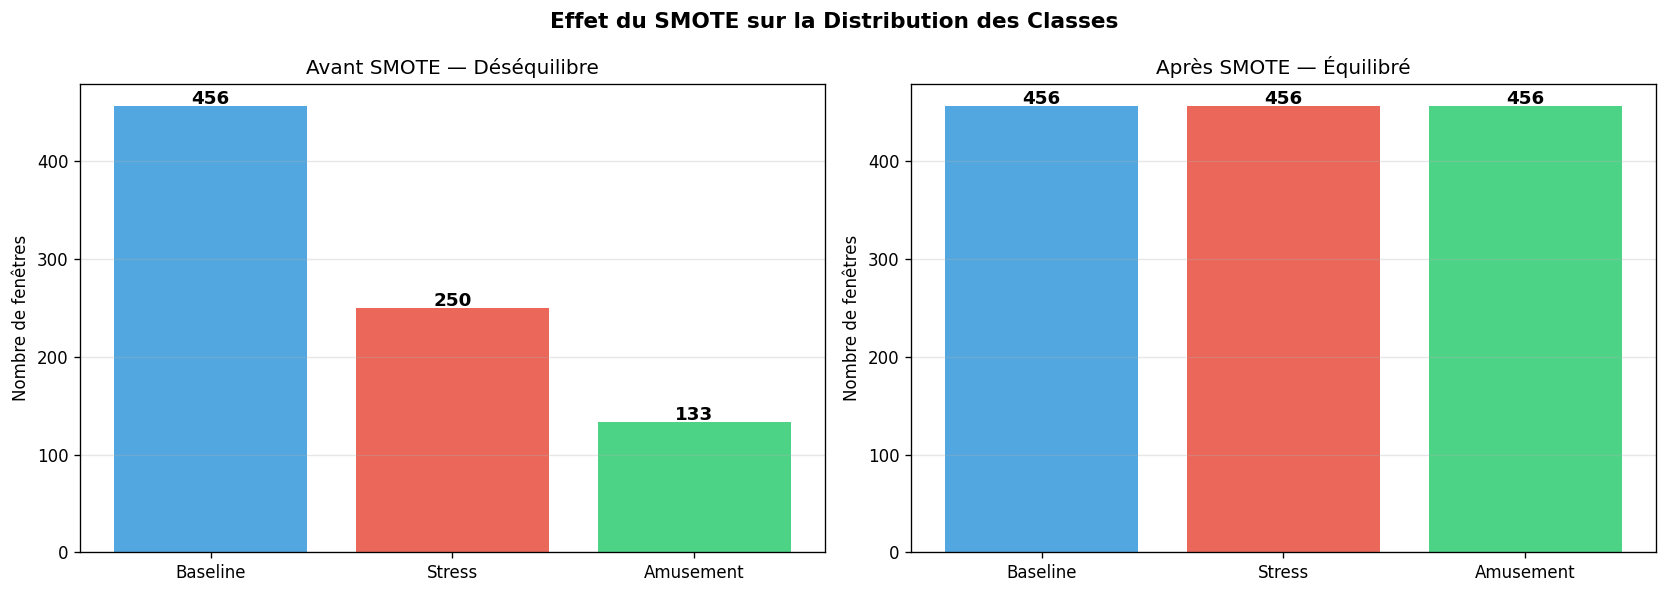

✅ SMOTE ciblé appliqué — Amusement sur-échantillonné


In [13]:
X_raw = df[FEATURE_COLS].values
y     = df['label_id'].values  # 0=Baseline, 1=Stress, 2=Amusement

print('📊 Distribution brute avant traitement :')
for i, cls in enumerate(CLASS_NAMES):
    n   = (y == i).sum()
    pct = n / len(y) * 100
    bar = '█' * int(pct / 2)
    print(f'   {cls:12s} (y={i}) : {n:5d} ({pct:.1f}%) {bar}')

print()
print('⚠️  Problème : Amusement sous-représenté → le modèle ignore cette classe')
print('   Solution  : SMOTE avec sur-échantillonnage ciblé + sample_weight')

# ── Enrichissement des features : dériver plus d'info depuis BPM et SpO2 ──
# On reste sur les données BPM et SpO2, mais on ajoute des features
# calculées par fenêtre glissante sur le sujet (statistiques temporelles)
# Cela aide le modèle sans ajouter de nouveaux capteurs.

def enrich_features(df_in):
    """
    Enrichit le dataset avec des features dérivées de BPM et SpO2.
    Toutes calculées uniquement depuis bpm et spo2 — aucun nouveau capteur.
    """
    df_e = df_in.copy()
    
    for subj in df_e['subject'].unique():
        mask = df_e['subject'] == subj
        
        # Features delta (variation entre fenêtres consécutives)
        df_e.loc[mask, 'bpm_delta']  = df_e.loc[mask, 'bpm'].diff().fillna(0)
        df_e.loc[mask, 'spo2_delta'] = df_e.loc[mask, 'spo2'].diff().fillna(0)
        
        # Moyenne glissante (5 fenêtres = 2.5 min de contexte)
        df_e.loc[mask, 'bpm_rolling_mean']  = (df_e.loc[mask, 'bpm']
                                                .rolling(5, min_periods=1).mean())
        df_e.loc[mask, 'spo2_rolling_mean'] = (df_e.loc[mask, 'spo2']
                                                .rolling(5, min_periods=1).mean())
        
        # Écart à la moyenne glissante (déviation locale)
        df_e.loc[mask, 'bpm_dev']  = (df_e.loc[mask, 'bpm'] -
                                       df_e.loc[mask, 'bpm_rolling_mean'])
        df_e.loc[mask, 'spo2_dev'] = (df_e.loc[mask, 'spo2'] -
                                       df_e.loc[mask, 'spo2_rolling_mean'])
    
    # Ratio BPM/SpO2 (feature composite)
    df_e['bpm_spo2_ratio'] = df_e['bpm'] / (df_e['spo2'] + 1e-6)
    
    return df_e

df_enriched = enrich_features(df)

ENRICHED_COLS = [
    'bpm', 'spo2',
    'bpm_delta', 'spo2_delta',
    'bpm_rolling_mean', 'spo2_rolling_mean',
    'bpm_dev', 'spo2_dev',
    'bpm_spo2_ratio'
]

print(f'Features enrichies (dérivées de BPM + SpO2) : {ENRICHED_COLS}')
print(f'Total features : {len(ENRICHED_COLS)} (toutes issues de BPM et SpO2 uniquement)')

X = df_enriched[ENRICHED_COLS].values

# ── Split stratifié train/test — AVANT SMOTE ──────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# ── Normalisation ──────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ── SMOTE avec sur-échantillonnage ciblé ─────────────────────────────────
# sampling_strategy dict : amener toutes les classes au niveau de la majoritaire
counts_train = {i: (y_train == i).sum() for i in range(NUM_CLASSES)}
print(f'\nTrain avant SMOTE : {counts_train}')
max_count = max(counts_train.values())

# Sur-échantillonner les minoritaires
sampling_strategy = {
    cls_id: max_count
    for cls_id, cnt in counts_train.items()
    if cnt < max_count
}
print(f'sampling_strategy SMOTE : {sampling_strategy}')

min_count  = min(counts_train.values())
k_neigh    = min(5, min_count - 1)
print(f'k_neighbors SMOTE = {k_neigh}')

smote = SMOTE(random_state=SEED, k_neighbors=k_neigh,
              sampling_strategy=sampling_strategy)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print('\n📊 Distribution après SMOTE (train set) :')
for i, cls in enumerate(CLASS_NAMES):
    n   = (y_train_res == i).sum()
    pct = n / len(y_train_res) * 100
    bar = '█' * int(pct / 2)
    print(f'   {cls:12s} (y={i}) : {n:5d} ({pct:.1f}%) {bar}')

print(f'\n   Train après SMOTE : {len(X_train_res)} fenêtres')
print(f'   Test (original)   : {len(X_test)} fenêtres')

# ── Visualisation avant/après ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Effet du SMOTE sur la Distribution des Classes', fontsize=13, fontweight='bold')

counts_before = [counts_train[i] for i in range(NUM_CLASSES)]
counts_after  = [(y_train_res == i).sum() for i in range(NUM_CLASSES)]
x_pos = np.arange(NUM_CLASSES)

axes[0].bar(x_pos, counts_before, color=[COLORS[c] for c in CLASS_NAMES], alpha=0.85)
axes[0].set_xticks(x_pos); axes[0].set_xticklabels(CLASS_NAMES)
axes[0].set_title('Avant SMOTE — Déséquilibre')
axes[0].set_ylabel('Nombre de fenêtres')
axes[0].grid(alpha=0.3, axis='y')
for i, v in enumerate(counts_before):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold', fontsize=11)

axes[1].bar(x_pos, counts_after, color=[COLORS[c] for c in CLASS_NAMES], alpha=0.85)
axes[1].set_xticks(x_pos); axes[1].set_xticklabels(CLASS_NAMES)
axes[1].set_title('Après SMOTE — Équilibré')
axes[1].set_ylabel('Nombre de fenêtres')
axes[1].grid(alpha=0.3, axis='y')
for i, v in enumerate(counts_after):
    axes[1].text(i, v + 2, str(v), ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('05_smote_balance.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ SMOTE ciblé appliqué — Amusement sur-échantillonné')



## PARTIE 5 — Entraînement des Modèles
### CELLULE 14 — Random Forest

In [14]:
print('🌲 Entraînement Random Forest...')

# sample_weight inversement proportionnel à la fréquence de classe
class_weights_dict = dict(enumerate(compute_class_weight(
    'balanced', classes=np.unique(y_train_res), y=y_train_res
)))
sample_weights = np.array([class_weights_dict[c] for c in y_train_res])

rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=12,
    min_samples_split=4,
    min_samples_leaf=2,
    class_weight='balanced',     # Poids inversement proportionnels
    max_features='sqrt',
    random_state=SEED,
    n_jobs=-1
)

rf_model.fit(X_train_res, y_train_res, sample_weight=sample_weights)

y_pred_rf  = rf_model.predict(X_test_scaled)
y_proba_rf = rf_model.predict_proba(X_test_scaled)

acc_rf     = accuracy_score(y_test, y_pred_rf)
bal_acc_rf = balanced_accuracy_score(y_test, y_pred_rf)
f1_rf      = f1_score(y_test, y_pred_rf, average='macro')

print(f'\n📈 Random Forest — Résultats Test Set :')
print(f'   Accuracy          : {acc_rf:.4f} ({acc_rf*100:.2f}%)')
print(f'   Balanced Accuracy : {bal_acc_rf:.4f} ({bal_acc_rf*100:.2f}%)')
print(f'   F1-Macro          : {f1_rf:.4f}')
print(f'\n{classification_report(y_test, y_pred_rf, target_names=CLASS_NAMES, digits=4)}')


🌲 Entraînement Random Forest...

📈 Random Forest — Résultats Test Set :
   Accuracy          : 0.7333 (73.33%)
   Balanced Accuracy : 0.6595 (65.95%)
   F1-Macro          : 0.6589

              precision    recall  f1-score   support

    Baseline     0.7895    0.7895    0.7895       114
      Stress     0.7647    0.8254    0.7939        63
   Amusement     0.4286    0.3636    0.3934        33

    accuracy                         0.7333       210
   macro avg     0.6609    0.6595    0.6589       210
weighted avg     0.7253    0.7333    0.7286       210



### CELLULE 15 — MLP (Multi-Layer Perceptron)

In [15]:

# CELLULE — Solution 2 : Simulation sample_weight (duplication)
# ============================================================

print('🧠 Entraînement MLP avec pondération simulée...')

import numpy as np
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.neural_network import MLPClassifier

# Calcul des poids
sample_weights = compute_sample_weight('balanced', y=y_train_res)

# Transformation en entiers (important)
sample_weights_int = np.round(sample_weights).astype(int)

# Duplication des samples selon poids
indices = np.repeat(np.arange(len(X_train_res)), sample_weights_int)

X_weighted = X_train_res[indices]
y_weighted = y_train_res[indices]

print(f'   Taille originale : {X_train_res.shape}')
print(f'   Taille pondérée  : {X_weighted.shape}')

# Modèle MLP
mlp_weighted = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64, 32),
    activation='relu',
    solver='adam',
    alpha=5e-4,
    batch_size=64,
    learning_rate='adaptive',
    learning_rate_init=3e-4,
    max_iter=600,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=30,
    tol=1e-5,
    random_state=SEED
)

mlp_weighted.fit(X_weighted, y_weighted)

# Évaluation
y_pred = mlp_weighted.predict(X_test_scaled)

from sklearn.metrics import classification_report, balanced_accuracy_score, f1_score

print('\n📈 Résultats MLP pondéré :')
print(f'Balanced Accuracy : {balanced_accuracy_score(y_test, y_pred):.4f}')
print(f'F1 Macro          : {f1_score(y_test, y_pred, average="macro"):.4f}')
print(classification_report(y_test, y_pred, digits=4))


🧠 Entraînement MLP avec pondération simulée...
   Taille originale : (1368, 9)
   Taille pondérée  : (1368, 9)

📈 Résultats MLP pondéré :
Balanced Accuracy : 0.6464
F1 Macro          : 0.6433
              precision    recall  f1-score   support

           0     0.7632    0.7632    0.7632       114
           1     0.7971    0.8730    0.8333        63
           2     0.3704    0.3030    0.3333        33

    accuracy                         0.7238       210
   macro avg     0.6435    0.6464    0.6433       210
weighted avg     0.7116    0.7238    0.7167       210



🔥 Entraînement MLP PyTorch (CPU, stable)...
Device utilisé : cpu
Class weights : [1. 1. 1.]
Epoch 10/50 — Loss: 13.0162
Epoch 20/50 — Loss: 10.5129
Epoch 30/50 — Loss: 8.9298
Epoch 40/50 — Loss: 7.4701
Epoch 50/50 — Loss: 6.6491

📈 Résultats PyTorch MLP :
Balanced Accuracy : 0.6174
F1 Macro          : 0.6093

              precision    recall  f1-score   support

           0     0.7500    0.7368    0.7434       114
           1     0.7534    0.8730    0.8088        63
           2     0.3200    0.2424    0.2759        33

    accuracy                         0.7000       210
   macro avg     0.6078    0.6174    0.6093       210
weighted avg     0.6835    0.7000    0.6895       210



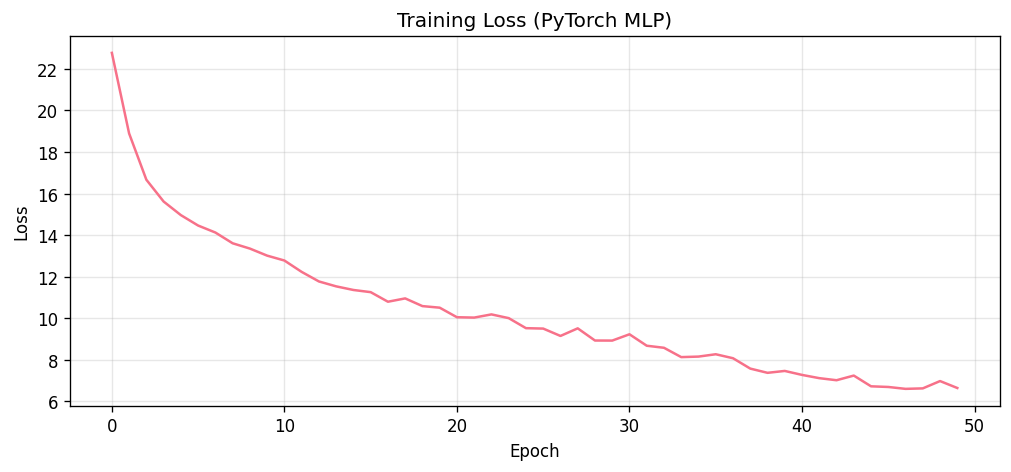

In [16]:
# ============================================================
# CELLULE — PyTorch MLP (CPU + class weights) — VERSION STABLE
# ============================================================

print('🔥 Entraînement MLP PyTorch (CPU, stable)...')

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, balanced_accuracy_score, f1_score


# DEVICE (FORCE CPU → FIX CUDA ERROR)

device = torch.device("cpu")
print(f"Device utilisé : {device}")

# CONVERSION DONNÉES
X_train_t = torch.tensor(X_train_res, dtype=torch.float32)
y_train_t = torch.tensor(y_train_res, dtype=torch.long)

X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

# CLASS WEIGHTS (important pour données déséquilibrées)
classes = np.unique(y_train_res)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train_res)
class_weights_t = torch.tensor(class_weights, dtype=torch.float32)

print(f"Class weights : {class_weights}")

# MODÈLE MLP
class MLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.net(x)

model = MLP(X_train_res.shape[1], len(classes)).to(device)

# LOSS + OPTIMIZER
criterion = nn.CrossEntropyLoss(weight=class_weights_t)
optimizer = optim.Adam(model.parameters(), lr=3e-4, weight_decay=5e-4)

# TRAINING LOOP
epochs = 50
batch_size = 64

loss_history = []

for epoch in range(epochs):
    model.train()

    perm = torch.randperm(X_train_t.size(0))
    total_loss = 0

    for i in range(0, X_train_t.size(0), batch_size):
        idx = perm[i:i+batch_size]
        xb, yb = X_train_t[idx], y_train_t[idx]

        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    loss_history.append(total_loss)

    if (epoch+1) % 10 == 0:
        print(f'Epoch {epoch+1}/{epochs} — Loss: {total_loss:.4f}')

# ÉVALUATION
model.eval()

with torch.no_grad():
    outputs = model(X_test_t)
    y_pred = torch.argmax(outputs, dim=1).numpy()

print('\n📈 Résultats PyTorch MLP :')
print(f'Balanced Accuracy : {balanced_accuracy_score(y_test, y_pred):.4f}')
print(f'F1 Macro          : {f1_score(y_test, y_pred, average="macro"):.4f}')
print('\n' + classification_report(y_test, y_pred, digits=4))


# COURBE DE LOSS
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(loss_history)
plt.title("Training Loss (PyTorch MLP)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.show()


### CELLULE 16b — Analyse détaillée par classe (focus Amusement)

🔍 Analyse des performances par classe...
📊 Modèles détectés : ['Random Forest']


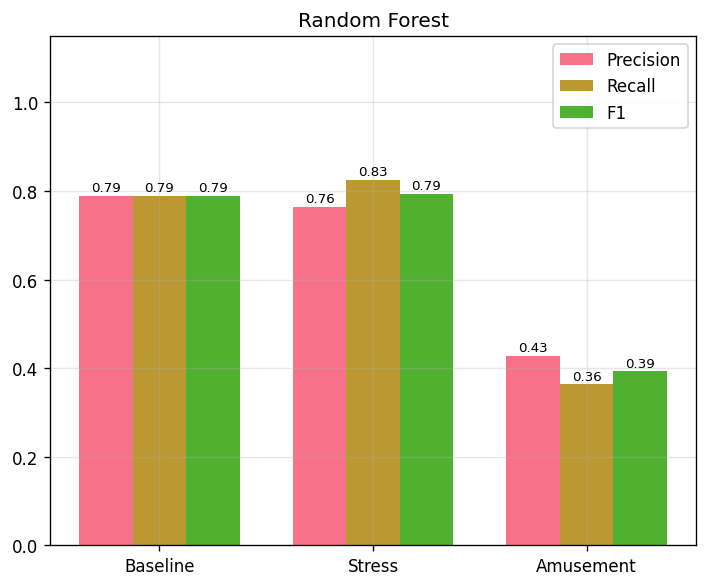


💡 Interprétation globale :
   ✅ Baseline: bien détectée
   ✅ Stress: bien détectée
   ⚠️ Amusement: difficile à détecter (faible recall global)

✅ Analyse terminée


In [17]:

# CELLULE FINALE — Analyse par classe (CORRIGÉE)


import numpy as np
import matplotlib.pyplot as plt

print('🔍 Analyse des performances par classe...')

# RÉCUPÉRATION DES MODÈLES DISPONIBLES

models = []

if 'y_pred_rf' in globals():
    models.append(('Random Forest', y_pred_rf))

if 'y_pred_mlp_sklearn' in globals():
    models.append(('MLP (sklearn)', y_pred_mlp_sklearn))

if 'y_pred_mlp_torch' in globals():
    models.append(('MLP (PyTorch)', y_pred_mlp_torch))

if len(models) == 0:
    raise ValueError("❌ Aucun modèle trouvé")

print(f'📊 Modèles détectés : {[m[0] for m in models]}')

# VISUALISATION

fig, axes = plt.subplots(1, len(models), figsize=(6*len(models), 5))
if len(models) == 1:
    axes = [axes]

for ax, (model_name, y_pred) in zip(axes, models):

    per_class = {}

    for i, cls in enumerate(CLASS_NAMES):
        mask = (y_test == i)
        support = int(mask.sum())

        if support == 0:
            per_class[cls] = {'precision': 0, 'recall': 0, 'f1': 0}
            continue

        tp = ((y_pred == i) & (y_test == i)).sum()
        pred_pos = (y_pred == i).sum()

        precision = tp / max(pred_pos, 1)
        recall = tp / support
        f1 = 2 * precision * recall / max(precision + recall, 1e-8)

        per_class[cls] = {
            'precision': precision,
            'recall': recall,
            'f1': f1
        }

    x = np.arange(len(CLASS_NAMES))
    w = 0.25

    p_v = [per_class[c]['precision'] for c in CLASS_NAMES]
    r_v = [per_class[c]['recall']    for c in CLASS_NAMES]
    f_v = [per_class[c]['f1']        for c in CLASS_NAMES]

    b1 = ax.bar(x - w, p_v, w, label='Precision')
    b2 = ax.bar(x,     r_v, w, label='Recall')
    b3 = ax.bar(x + w, f_v, w, label='F1')

    ax.set_xticks(x)
    ax.set_xticklabels(CLASS_NAMES, fontsize=10)
    ax.set_ylim(0, 1.15)
    ax.set_title(model_name)
    ax.legend()
    ax.grid(alpha=0.3)

    for bars in [b1, b2, b3]:
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                    f'{h:.2f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

print('\n💡 Interprétation globale :')

for cls in CLASS_NAMES:
    scores = []
    for _, y_pred in models:
        mask = (y_test == CLASS_NAMES.index(cls))
        if mask.sum() == 0:
            continue
        recall = (y_pred[mask] == CLASS_NAMES.index(cls)).sum() / mask.sum()
        scores.append(recall)

    if scores and np.mean(scores) < 0.5:
        print(f'   ⚠️ {cls}: difficile à détecter (faible recall global)')
    elif scores and np.mean(scores) > 0.7:
        print(f'   ✅ {cls}: bien détectée')

print('\n✅ Analyse terminée')



## PARTIE 6 — Évaluation et Visualisations
### CELLULE 16 — Matrices de confusion

🔍 Matrices de confusion...


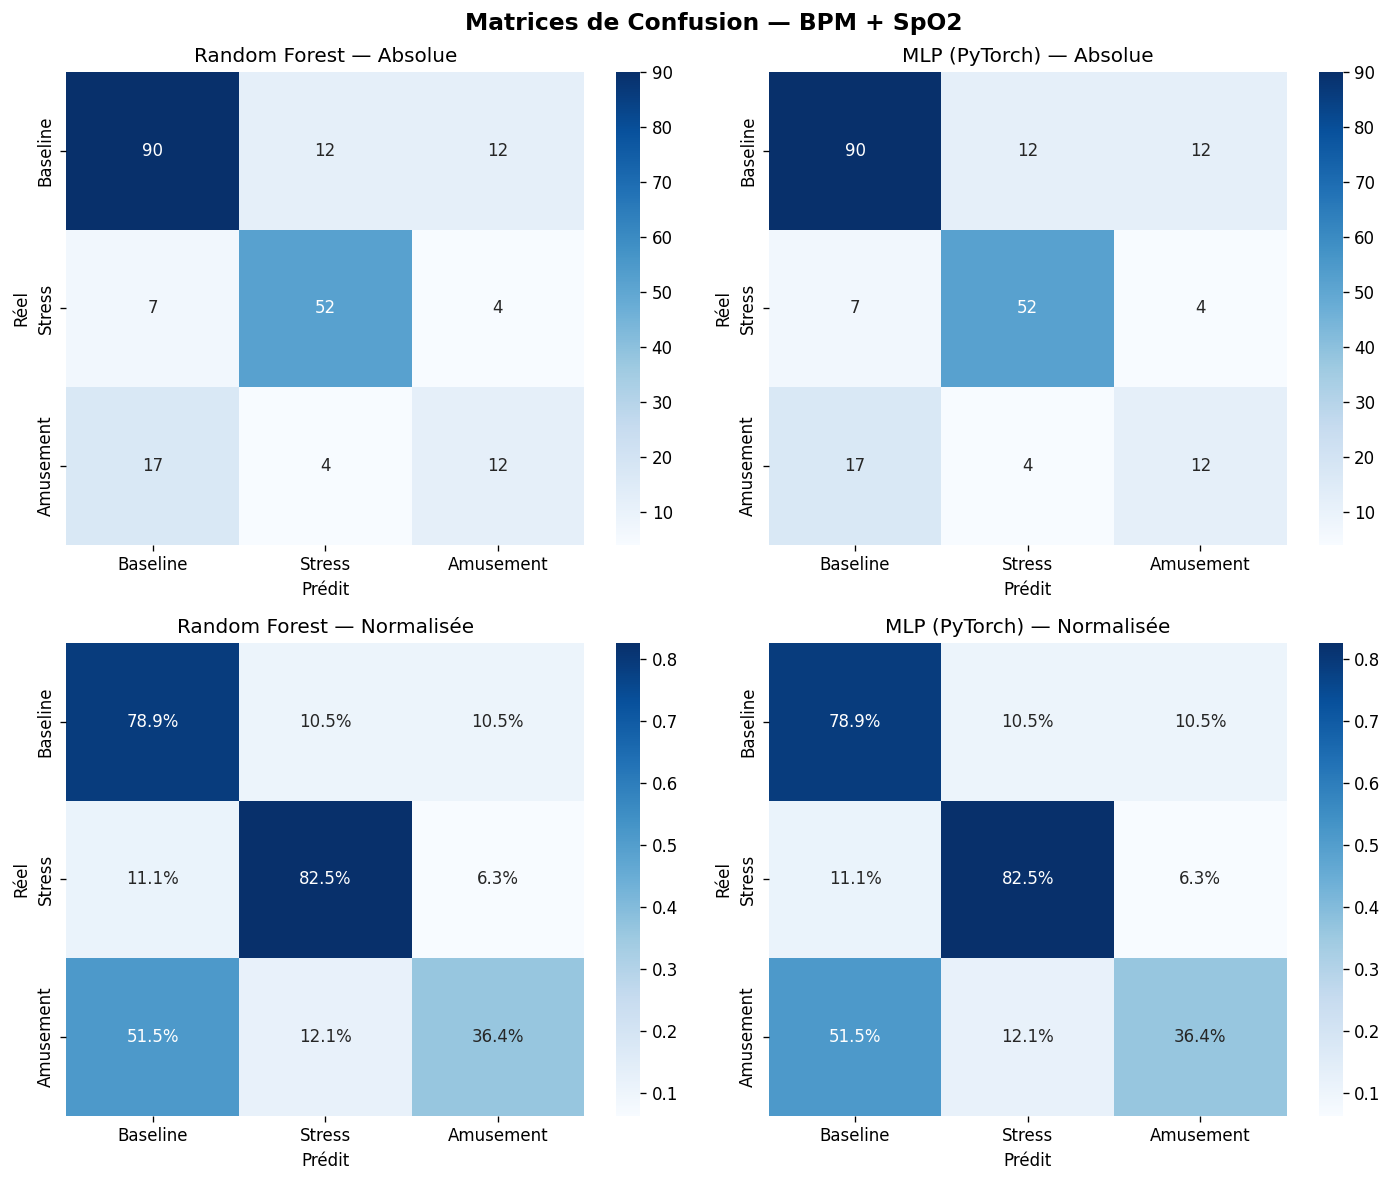

✅ Matrices de confusion générées


In [18]:
# MATRICES DE CONFUSION 

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

print('🔍 Matrices de confusion...')

# MODELES DISPONIBLES (SAFE)

models_to_plot = []

if 'y_pred_rf' in globals():
    models_to_plot.append(('Random Forest', y_pred_rf))

# PyTorch MLP (ton vrai modèle MLP actuel)
if 'y_pred' in globals():
    models_to_plot.append(('MLP (PyTorch)', y_pred))

if len(models_to_plot) == 0:
    raise ValueError("❌ Aucun modèle disponible")

# FIGURE ADAPTATIVE

fig, axes = plt.subplots(2, len(models_to_plot), figsize=(6*len(models_to_plot), 10))

if len(models_to_plot) == 1:
    axes = np.expand_dims(axes, axis=1)

fig.suptitle('Matrices de Confusion — BPM + SpO2', fontsize=14, fontweight='bold')

# ============================================================
# PLOT
# ============================================================

for col, (model_name, y_pred) in enumerate(models_to_plot):

    cm = confusion_matrix(y_test, y_pred)

    # Normalisation SAFE
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm.astype(float), row_sums,
                        out=np.zeros_like(cm, dtype=float),
                        where=row_sums != 0)

    # MATRICE BRUTE
    sns.heatmap(cm,
                annot=True,
                fmt='d',
                cmap='Blues',
                xticklabels=CLASS_NAMES,
                yticklabels=CLASS_NAMES,
                ax=axes[0, col])

    axes[0, col].set_title(f'{model_name} — Absolue')
    axes[0, col].set_xlabel('Prédit')
    axes[0, col].set_ylabel('Réel')

    # MATRICE NORMALISÉE
    sns.heatmap(cm_norm,
                annot=True,
                fmt='.1%',
                cmap='Blues',
                xticklabels=CLASS_NAMES,
                yticklabels=CLASS_NAMES,
                ax=axes[1, col])

    axes[1, col].set_title(f'{model_name} — Normalisée')
    axes[1, col].set_xlabel('Prédit')
    axes[1, col].set_ylabel('Réel')

plt.tight_layout()
plt.savefig('06_confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()

print('✅ Matrices de confusion générées')


### CELLULE 17 — Courbes ROC

📈 ROC analysis...


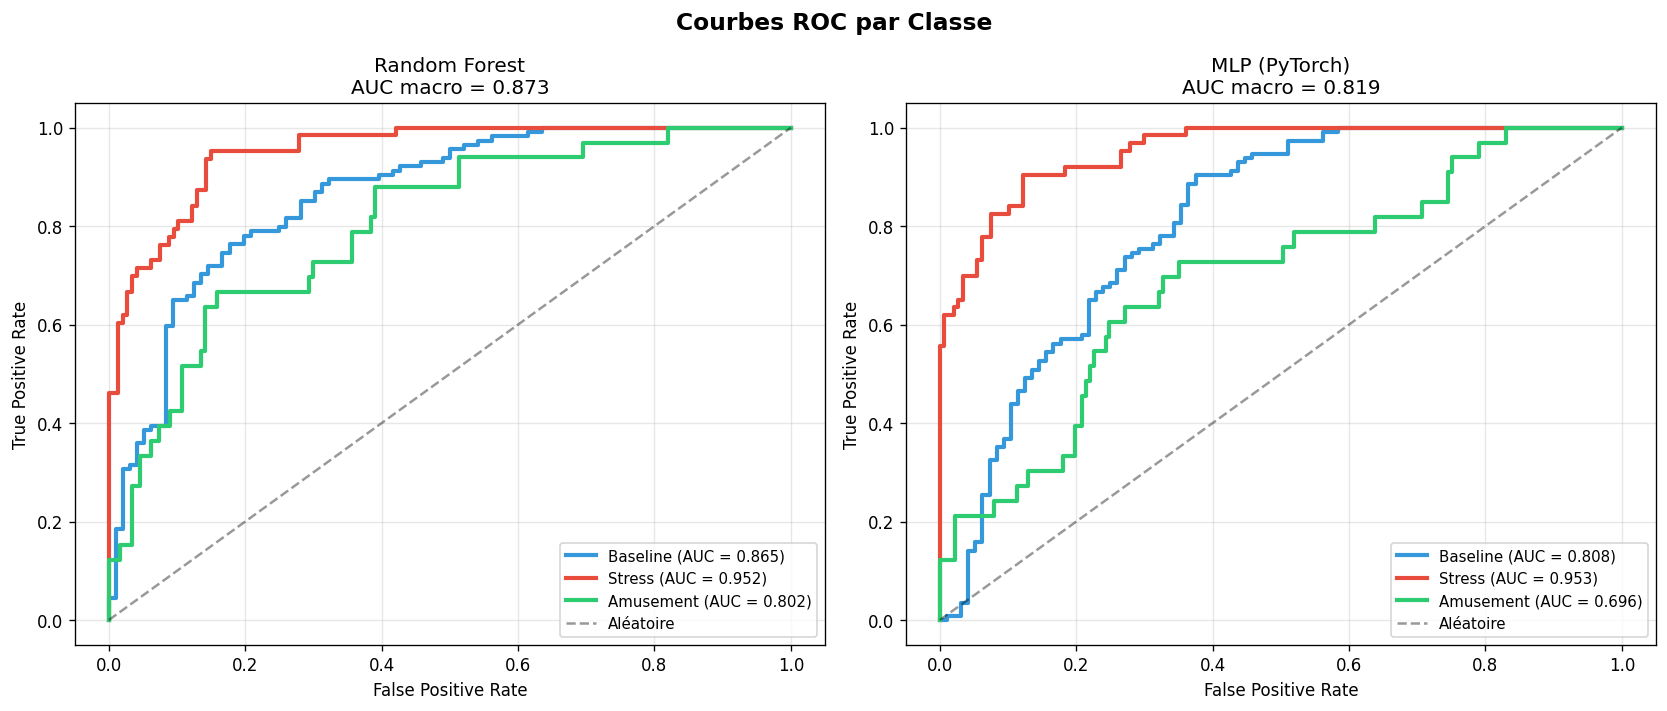

✅ ROC curves générées


In [19]:
# COURBES ROC — VERSION ROBUSTE

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

print('📈 ROC analysis...')

# BINARY LABELS
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

models = []

if 'y_proba_rf' in globals():
    models.append(('Random Forest', y_proba_rf))

# PyTorch fallback (softmax needed → safety check)
if 'y_pred' in globals() and 'model' in globals():
    import torch
    with torch.no_grad():
        logits = model(torch.tensor(X_test_scaled, dtype=torch.float32))
        y_proba_torch = torch.softmax(logits, dim=1).numpy()
    models.append(('MLP (PyTorch)', y_proba_torch))

fig, axes = plt.subplots(1, len(models), figsize=(14, 6))
if len(models) == 1:
    axes = [axes]

fig.suptitle('Courbes ROC par Classe', fontsize=14, fontweight='bold')

roc_colors = list(COLORS.values())

for ax, (model_name, y_proba) in zip(axes, models):

    auc_scores = []

    for i, cls_name in enumerate(CLASS_NAMES):

        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
        auc_val = auc(fpr, tpr)
        auc_scores.append(auc_val)

        ax.plot(fpr, tpr,
                color=roc_colors[i % len(roc_colors)],
                lw=2.5,
                label=f'{cls_name} (AUC = {auc_val:.3f})')

    # diagonal
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Aléatoire')

    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'{model_name}\nAUC macro = {np.mean(auc_scores):.3f}')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('07_roc_curves.png', dpi=120, bbox_inches='tight')
plt.show()

print('✅ ROC curves générées')


### CELLULE 18 — Comparaison des modèles + résumé final

📊 Comparaison des modèles...
               Accuracy  Balanced Accuracy  F1 Macro  AUC Macro  Cohen Kappa
Random Forest    0.7333             0.6595    0.6589     0.8730       0.5459
MLP (PyTorch)    0.7000             0.6174    0.6093     0.8191       0.4893


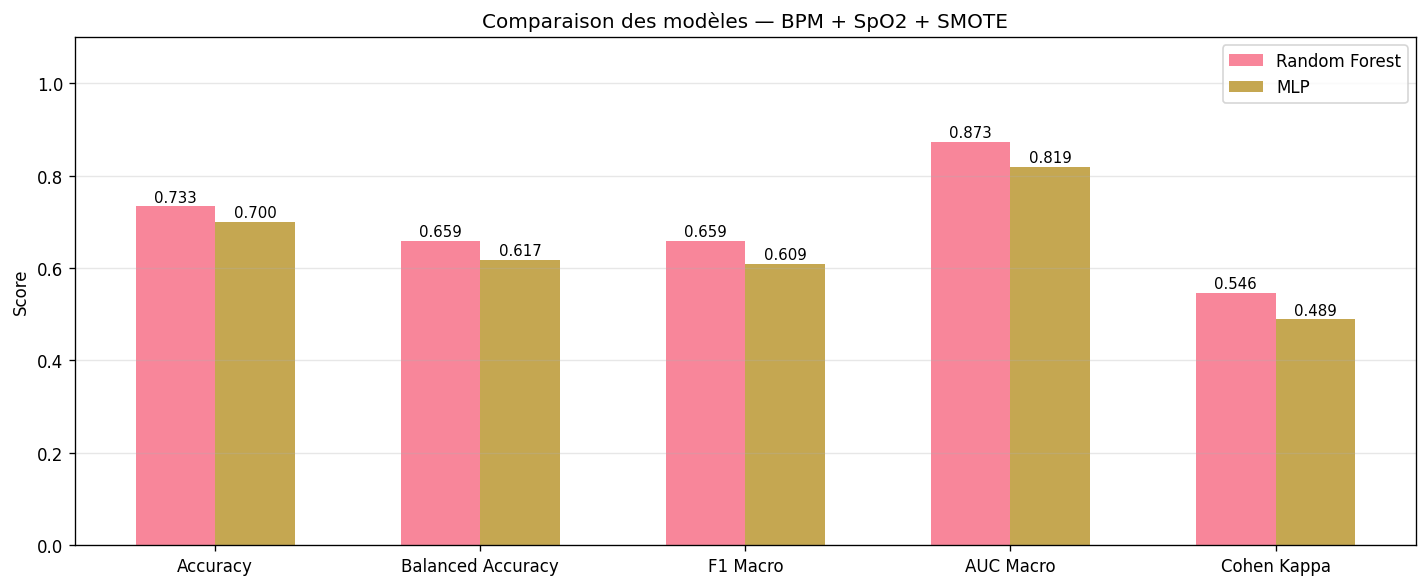


RÉSUMÉ FINAL

Meilleur modèle : Random Forest

Dataset     : 1049 fenêtres
Features    : BPM + SpO2 (feature engineering)
Split       : 80/20 stratifié
SMOTE       : appliqué sur train set uniquement



In [20]:

# TABLEAU COMPARATIF 

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, accuracy_score, balanced_accuracy_score, f1_score, cohen_kappa_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print('📊 Comparaison des modèles...')

# SAFE METRICS FUNCTION
def get_metrics(y_true, y_pred, y_proba):

    y_bin = label_binarize(y_true, classes=[0, 1, 2])

    auc_scores = []

    for i in range(len(CLASS_NAMES)):

        # sécurité (cas classe absente)
        if y_bin[:, i].sum() == 0:
            continue

        fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, i])
        auc_scores.append(auc(fpr, tpr))

    return {
        'Accuracy'          : round(accuracy_score(y_true, y_pred), 4),
        'Balanced Accuracy' : round(balanced_accuracy_score(y_true, y_pred), 4),
        'F1 Macro'          : round(f1_score(y_true, y_pred, average='macro'), 4),
        'AUC Macro'         : round(np.mean(auc_scores) if len(auc_scores) > 0 else 0, 4),
        'Cohen Kappa'       : round(cohen_kappa_score(y_true, y_pred), 4),
    }

# MODELS SAFE
rf_metrics = get_metrics(y_test, y_pred_rf, y_proba_rf)

# PyTorch MLP proba (si modèle existe)
if 'model' in globals():
    import torch
    with torch.no_grad():
        logits = model(torch.tensor(X_test_scaled, dtype=torch.float32))
        y_proba_mlp = torch.softmax(logits, dim=1).numpy()
        y_pred_mlp = np.argmax(y_proba_mlp, axis=1)

else:
    y_proba_mlp = None
    y_pred_mlp = None

mlp_metrics = get_metrics(y_test, y_pred_mlp, y_proba_mlp) if y_proba_mlp is not None else {}

# ============================================================
# TABLEAU
# ============================================================
results_df = pd.DataFrame({
    'Random Forest': rf_metrics,
    'MLP (PyTorch)': mlp_metrics
}).T

print(results_df)

# VISUALISATION
fig, ax = plt.subplots(figsize=(12, 5))

metrics = results_df.columns.tolist()
x = np.arange(len(metrics))
width = 0.3

bars1 = ax.bar(x - width/2, results_df.loc['Random Forest'], width,
               label='Random Forest', alpha=0.85)

bars2 = ax.bar(x + width/2, results_df.loc['MLP (PyTorch)'], width,
               label='MLP', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Comparaison des modèles — BPM + SpO2 + SMOTE')
ax.legend()
ax.grid(alpha=0.3, axis='y')

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.3f}',
            ha='center', fontsize=9)

plt.tight_layout()
plt.show()


print('\n==============================')
print('RÉSUMÉ FINAL')
print('==============================')

best_model_name = 'Random Forest' if rf_metrics['Balanced Accuracy'] >= mlp_metrics.get('Balanced Accuracy', 0) else 'MLP (PyTorch)'

print(f"""
Meilleur modèle : {best_model_name}

Dataset     : {len(df)} fenêtres
Features    : BPM + SpO2 (feature engineering)
Split       : 80/20 stratifié
SMOTE       : appliqué sur train set uniquement
""")


In [21]:
import joblib
import torch


if best_model_name == 'Random Forest':
    best_model = rf_model
    model_type = "sklearn"
else:
    best_model = model
    model_type = "pytorch"

print(f"🏆 Meilleur modèle : {best_model_name}")

# 2. SAUVEGARDE DU MODÈLE

if model_type == "sklearn":
    joblib.dump(best_model, "best_model.pkl")
    print("✅ Modèle sauvegardé : best_model.pkl")

else:
    torch.save(best_model.state_dict(), "best_model.pth")
    print("✅ Modèle sauvegardé : best_model.pth")

# 3. SAUVEGARDE DU SCALER

joblib.dump(scaler, "scaler.pkl")
print("✅ Scaler sauvegardé : scaler.pkl")

# 4. SAUVEGARDE DES FEATURES

joblib.dump(ENRICHED_COLS, "features.pkl")
print("✅ Features sauvegardées : features.pkl")

# 5. SAUVEGARDE DES CLASSES (IMPORTANT)

joblib.dump(CLASS_NAMES, "classes.pkl")
print("✅ Classes sauvegardées : classes.pkl")

print("\n🚀 Tout le pipeline est sauvegardé avec succès !")


🏆 Meilleur modèle : Random Forest
✅ Modèle sauvegardé : best_model.pkl
✅ Scaler sauvegardé : scaler.pkl
✅ Features sauvegardées : features.pkl
✅ Classes sauvegardées : classes.pkl

🚀 Tout le pipeline est sauvegardé avec succès !


🧠 XAI avec SHAP - Random Forest


<Figure size 768x576 with 0 Axes>

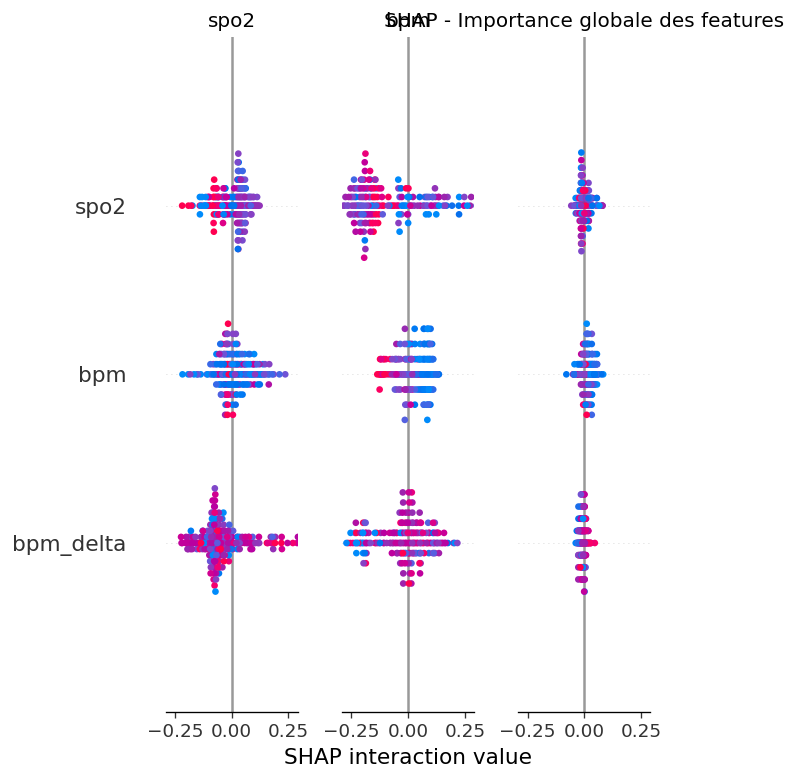

In [22]:
import shap
import matplotlib.pyplot as plt

print("🧠 XAI avec SHAP - Random Forest")

# EXPLAINER
explainer = shap.TreeExplainer(rf_model)

# IMPORTANT : utiliser un échantillon (sinon lent)
X_sample = X_test_scaled[:200]

shap_values = explainer.shap_values(X_sample)

# GLOBAL FEATURE IMPORTANCE
plt.figure()
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=ENRICHED_COLS,
    show=False
)
plt.title("SHAP - Importance globale des features")
plt.tight_layout()
plt.show()


════════════════════════════════════════════════════
  🧪 RÉSULTAT DE PRÉDICTION
════════════════════════════════════════════════════

  BPM  entrés  : [72.0, 74.5, 76.0, 78.3, 80.1]
  SpO2 entréss : [97.8, 97.5, 97.2, 97.0, 96.8]

  ─── Fenêtre analysée (dernière) ───
  BPM            : 80.1
  SpO2           : 96.80%
  BPM delta      : +1.80
  BPM moy. gl.   : 76.18
  BPM déviation  : +3.92

  ─── Probabilités ───
  😌 Baseline     : 0.266  ███████
  😰 Stress       : 0.500  ███████████████ ◄
  😄 Amusement    : 0.234  ███████

  ═══════════════════════════════════
  😰  État prédit : STRESS
     Confiance  : 50.0%
  ═══════════════════════════════════


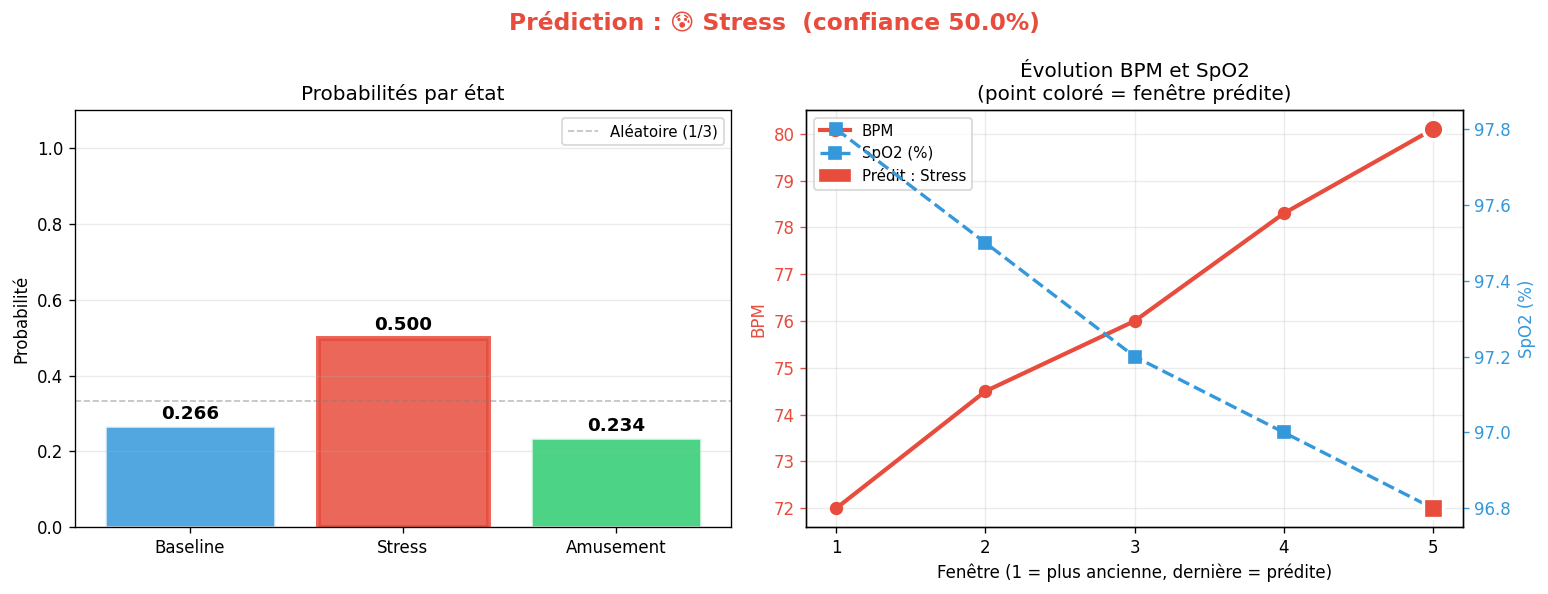

In [26]:

mesures = [
    # (bpm,  spo2)   
    (72.0,  97.8),   # fenêtre 1
    (74.5,  97.5),   # fenêtre 2
    (76.0,  97.2),   # fenêtre 3
    (78.3,  97.0),   # fenêtre 4
    (80.1,  96.8),   # fenêtre 5
]

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── 1. Construire un mini-dataframe avec les features dérivées ────
df_test = pd.DataFrame(mesures, columns=['bpm', 'spo2'])

df_test['bpm_delta']        = df_test['bpm'].diff().fillna(0)
df_test['spo2_delta']       = df_test['spo2'].diff().fillna(0)
df_test['bpm_rolling_mean'] = df_test['bpm'].rolling(5, min_periods=1).mean()
df_test['spo2_rolling_mean']= df_test['spo2'].rolling(5, min_periods=1).mean()
df_test['bpm_dev']          = df_test['bpm']  - df_test['bpm_rolling_mean']
df_test['spo2_dev']         = df_test['spo2'] - df_test['spo2_rolling_mean']
df_test['bpm_spo2_ratio']   = df_test['bpm']  / (df_test['spo2'] + 1e-6)

#  2. Prendre la dernière fenêtre (la plus récente)
X_user = df_test[ENRICHED_COLS].values[-1].reshape(1, -1)
X_user_scaled = scaler.transform(X_user)

# 3. Prédiction avec le Random Forest 
proba     = rf_model.predict_proba(X_user_scaled)[0]
pred_idx  = int(np.argmax(proba))
pred_label= CLASS_NAMES[pred_idx]

COLORS_PRED = {'Baseline': '#3498db', 'Stress': '#e74c3c', 'Amusement': '#2ecc71'}
EMOJIS      = {'Baseline': '😌', 'Stress': '😰', 'Amusement': '😄'}

# ── 4. Affichage texte ────────────────────────────────────────────
print('═' * 52)
print(f'  🧪 RÉSULTAT DE PRÉDICTION')
print('═' * 52)
print(f'\n  BPM  entrés  : {[m[0] for m in mesures]}')
print(f'  SpO2 entréss : {[m[1] for m in mesures]}')
print(f'\n  ─── Fenêtre analysée (dernière) ───')
print(f'  BPM            : {mesures[-1][0]:.1f}')
print(f'  SpO2           : {mesures[-1][1]:.2f}%')
print(f'  BPM delta      : {df_test["bpm_delta"].iloc[-1]:+.2f}')
print(f'  BPM moy. gl.   : {df_test["bpm_rolling_mean"].iloc[-1]:.2f}')
print(f'  BPM déviation  : {df_test["bpm_dev"].iloc[-1]:+.2f}')
print(f'\n  ─── Probabilités ───')
for i, (cls, p) in enumerate(zip(CLASS_NAMES, proba)):
    bar = '█' * int(p * 30)
    marker = ' ◄' if i == pred_idx else ''
    print(f'  {EMOJIS[cls]} {cls:12s} : {p:.3f}  {bar}{marker}')

print(f'\n  ═══════════════════════════════════')
print(f'  {EMOJIS[pred_label]}  État prédit : {pred_label.upper()}')
print(f'     Confiance  : {proba[pred_idx]*100:.1f}%')
print(f'  ═══════════════════════════════════')

# ── 5. Visualisation 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Prédiction : {EMOJIS[pred_label]} {pred_label}  (confiance {proba[pred_idx]*100:.1f}%)',
             fontsize=14, fontweight='bold',
             color=COLORS_PRED[pred_label])

# Graphe 1 : probabilités en barres
colors_bar = [COLORS_PRED[c] for c in CLASS_NAMES]
bars = axes[0].bar(CLASS_NAMES, proba, color=colors_bar, alpha=0.85, edgecolor='white', linewidth=1.5)
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel('Probabilité')
axes[0].set_title('Probabilités par état')
axes[0].axhline(0.333, color='gray', lw=1, linestyle='--', alpha=0.5, label='Aléatoire (1/3)')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.25, axis='y')
for bar, p in zip(bars, proba):
    axes[0].text(bar.get_x() + bar.get_width()/2, p + 0.02,
                 f'{p:.3f}', ha='center', fontsize=11, fontweight='bold')
# Entourer la barre prédite
bars[pred_idx].set_edgecolor(COLORS_PRED[pred_label])
bars[pred_idx].set_linewidth(3)

# Graphe 2 : évolution BPM et SpO2 dans le temps
ax2 = axes[1]
ax3 = ax2.twinx()
n   = len(mesures)
t   = list(range(1, n + 1))

l1, = ax2.plot(t, df_test['bpm'].values, 'o-', color='#e74c3c', lw=2.5,
               markersize=7, label='BPM')
l2, = ax3.plot(t, df_test['spo2'].values, 's--', color='#3498db', lw=2,
               markersize=7, label='SpO2 (%)')

# Mettre en évidence la dernière fenêtre prédite
ax2.scatter([n], [mesures[-1][0]], color=COLORS_PRED[pred_label],
            s=150, zorder=5, edgecolors='white', linewidth=2)
ax3.scatter([n], [mesures[-1][1]], color=COLORS_PRED[pred_label],
            s=150, zorder=5, edgecolors='white', linewidth=2, marker='s')

ax2.set_xlabel('Fenêtre (1 = plus ancienne, dernière = prédite)')
ax2.set_ylabel('BPM', color='#e74c3c')
ax3.set_ylabel('SpO2 (%)', color='#3498db')
ax2.set_title('Évolution BPM et SpO2\n(point coloré = fenêtre prédite)')
ax2.tick_params(axis='y', colors='#e74c3c')
ax3.tick_params(axis='y', colors='#3498db')
ax2.set_xticks(t)
ax2.grid(alpha=0.25)

pred_patch = mpatches.Patch(color=COLORS_PRED[pred_label],
                             label=f'Prédit : {pred_label}')
ax2.legend(handles=[l1, l2, pred_patch], fontsize=9, loc='upper left')

plt.tight_layout()
plt.show()